# Структура обработанного датасета DRP-372 (только образцы 256x256x256)

## Папки

- data/npy/ - бинарные 3D-структуры пород (файлы *.npy)
- data/csv/ - целевые значения проницаемости (файлы *.csv)

## Формат .npy (входные данные)

- Размерность = (256, 256, 256)
- Тип данных: float32 (0 - поровое пространство, 1 - твёрдая фаза)
- Загрузка: `vol = np.load("data/npy/204_03_256.npy")`

## Формат .csv (целевые переменные)

Каждый CSV в data/csv/ содержит 6 строк (давления 1,2,5,10,20 МПа и LBM):

| pressure | permeability |
|----------|--------------|
| 1        |       |
| 2        |       |
| 5        |       |
| 10       |       |
| 20       |      |
| LBM      |     |

- pressure: давление в МПа (для LBM - строка 'LBM')
- permeability: проницаемость (при отсутствии данных - NaN)

Также все csv объединены в один файл с именем "dataset_combined.csv", расположенный в корне проекта

## PyTorch Dataset

Класс PermDataset возвращает пару (volume, target_vector):
- volume: тензор (1, 256, 256, 256)
- target: тензор (6,)

```python
dataset = PermDataset()
vol, perm = dataset[0]  # vol.shape=(1,256,256,256), perm.shape=(6,)

In [ ]:
# @title Подгружаем библиотеки
%%capture
!pip install remotezip
!pip install pyvista # Данная библиотека предоставляет инструменты для отрисовки 3-D моделей
!pip install gudhi
!pip install giotto-tda
!pip install -U git+https://github.com/shizuo-kaji/CubicalRipser_3dim
!pip install "numpy<2.0" "scikit-learn==1.3.2" ripser persim

In [1]:
# @title Подключаем библиотеки и настраиваем среду
# %%capture
# numpy
import numpy as np
print(f"Current NumPy version: {np.__version__}")
if np.__version__.startswith('2.'):
    print("\n[!] ВНИМАНИЕ: Нужно перезапустить сессию (Runtime -> Restart session), чтобы изменения вступили в силу.")

np.set_printoptions(precision=2, suppress=True, linewidth=120)

# gudhi
import gudhi as gd
from gudhi import bottleneck_distance
from gudhi.hera import wasserstein_distance
from gudhi.representations import BettiCurve, PersistenceImage, Landscape

# giotto
from gtda.homology import VietorisRipsPersistence
# from gtda.diagrams import BettiCurve, PersistenceImage, PersistenceLandscape
from gtda.homology import CubicalPersistence
from gtda.plotting import plot_diagram
from gtda.images import Binarizer, HeightFiltration, RadialFiltration, DensityFiltration, DilationFiltration, ErosionFiltration, SignedDistanceFiltration
import gtda.plotting as gtdaplot

# ripser & persim
from ripser import lower_star_img, Rips
from persim import plot_diagrams

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, train_test_split, KFold
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.datasets import make_circles
from sklearn.metrics import r2_score, mean_absolute_error

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset, Subset
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
%matplotlib inline

# scipy
import scipy as sp
import scipy.stats as stats
from scipy.ndimage import zoom


import pyvista as pv
import scipy as sp
import pandas as pd
import os
import io
import h5py
import time
import gdown
import pickle
import psutil
import fnmatch
import zipfile
import cripser
import resource
import shutil
from remotezip import RemoteZip
from tqdm import tqdm
from IPython.display import Image, display, clear_output
from joblib import Parallel, delayed
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from collections import defaultdict

Current NumPy version: 1.26.4


# Подгрузка датасетов

## Получение и объединение .csv файлов с результатами симуляций, преобразование .mat -> .npy

In [ ]:
# @title Код подгрузки данных первого датасета на случай потери доступа к гугл диску
%%capture

# Код реорганизации данных
'''
url = "https://web.corral.tacc.utexas.edu/digitalporousmedia/archive/DRP-372/DRP-372_archive.zip"
os.makedirs("data/npy", exist_ok=True)
os.makedirs("data/csv", exist_ok=True)

def cb(name, obj):
  if isinstance(obj, h5py.Dataset) and obj.ndim == 3:
      return obj

def find_3d_dataset(h5_file):
  """Возвращает 3D массив или None."""
  ds = h5_file.visititems(cb)
  return ds

def get_permeability(csv_bytes):
  """Извлекает значение permeability из CSV."""
  try:
      text = csv_bytes.decode('utf-8')
      for line in text.splitlines():
          if 'permeability' in line.lower():
              parts = line.split(',')
              if len(parts) >= 2:
                  val = parts[1].strip()
                  if not val and len(parts) > 0:
                      val = parts[0].strip()
                  return float(val)
      return None
  except Exception as e:
      print(f"Ошибка парсинга: {e}")
      return None

with RemoteZip(url) as rz:
    all_files = rz.namelist()
    mat_files = [f for f in all_files if '_256.mat' in f and f.endswith('.mat')]

    for mat_path in tqdm(mat_files):
        name = mat_path.split('/')[-1][:-4]
        base_dir = '/'.join(mat_path.split('/')[:-1])

        #.mat -> .npy
        npy_path = f"data/npy/{name}.npy"
        if not os.path.exists(npy_path):
            try:
                rz.extract(mat_path, path='.')
                with h5py.File(mat_path, 'r') as hf:
                    vol = find_3d_dataset(hf)
                    if vol is not None:
                        np.save(npy_path, vol)
                os.remove(mat_path)
            except Exception as e:
                print(f"Ошибка при обработке {name}: {e}")
                continue

        # Поиск permeability
        perms = []
        pressures = [1,2,5,10,20,'LBM']
        for p in pressures:
            if p == 'LBM':
                pattern = f"{base_dir}/Single Phase*/LBM.csv"
            else:
                pattern = f"{base_dir}/Single Phase*/P_{p}_MPa.csv"
            matching = fnmatch.filter(all_files, pattern)
            if matching:
                csv_path = matching[0]
                try:
                    content = rz.read(csv_path)
                    perm = get_permeability(content)
                    perms.append(perm)
                except Exception as e:
                    print(f"Не удалось прочитать {csv_path}: {e}")
                    perms.append(None)
            else:
                perms.append(None)

        df_out = pd.DataFrame({'pressure': pressures, 'permeability': perms})
        df_out.to_csv(f"data/csv/{name}.csv", index=False)
        print(f"{name}: {perms}")
'''

In [ ]:
# @title Подгрузка первого датасета из гугл диска


ZIP_URL = "https://drive.google.com/uc?export=download&id=1R40Kau_i1qEG3ge0by_sFncIXz7d0rCw"
ZIP_PATH = "data.zip"
EXTRACT_DIR = "data"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива с данными...")
    gdown.download(ZIP_URL, ZIP_PATH, quiet=False)

    print("Распаковка архива...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово! Данные загружены в папку 'data'.")
else:
    print("Папка 'data' уже существует, пропускаем загрузку.")

Скачивание архива с данными...


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1R40Kau_i1qEG3ge0by_sFncIXz7d0rCw
From (redirected): https://drive.google.com/uc?export=download&id=1R40Kau_i1qEG3ge0by_sFncIXz7d0rCw&confirm=t&uuid=fbeebf6c-50a5-4e0d-ae7f-a2db69176fff
To: /content/data.zip
100%|██████████| 56.4M/56.4M [00:01<00:00, 35.0MB/s]


Распаковка архива...
Готово! Данные загружены в папку 'data'.


In [ ]:
#@title Отдельно достаём данные о функционале Минковского
# ID вашего ZIP-файла на Google Диске (из предоставленной ссылки)
FILE_ID = "1Od0F-d8nG94IHjlKjBSXpqSNx0o6_iL8"
ZIP_URL = f"https://drive.google.com/uc?export=download&id={FILE_ID}"
ZIP_PATH = "minkowski_data.zip"
MINKOWSKI_DIR = "./minkowski_data"

if not os.path.exists(MINKOWSKI_DIR):
    print("Скачивание архива...")
    gdown.download(ZIP_URL, ZIP_PATH, quiet=False)

    print("Распаковка архива...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(MINKOWSKI_DIR)

    os.remove(ZIP_PATH)
    print("Готово! Данные загружены в папку 'minkowski_data'.")
else:
    print(f"Папка '{MINKOWSKI_DIR}' уже существует, пропускаем загрузку.")

Скачивание архива...


Downloading...
From: https://drive.google.com/uc?export=download&id=1Od0F-d8nG94IHjlKjBSXpqSNx0o6_iL8
To: /content/minkowski_data.zip
100%|██████████| 19.5k/19.5k [00:00<00:00, 23.5MB/s]

Распаковка архива...
Готово! Данные загружены в папку 'minkowski_data'.


In [ ]:
# @title Подгрузим файл с именами горных пород

url = "https://docs.google.com/spreadsheets/d/1toagV4m4SN2T5RBMHSssU9RVSO4Zf9us/export?format=xlsx"
output = "metadata.xlsx"
gdown.download(url, output, quiet=False)

/usr/local/lib/python3.12/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1toagV4m4SN2T5RBMHSssU9RVSO4Zf9us/export?format=xlsx
To: /content/metadata.xlsx
14.3kB [00:00, 1.15MB/s]


'metadata.xlsx'

In [ ]:
# @title Подгрузка второго датасета (1000 вхождений), опционально

FILE_ID = "1uDh0Vxdo-xHBgdAmI0h_DjFGDkMCKoVa"
ZIP_PATH = "synthetic_data_256.zip"
EXTRACT_DIR = "synthetic_data_extracted"

def download_synthetic_zip():
    if not os.path.exists(ZIP_PATH):
        print("Скачиваем архив с Google Диска...")
        gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)
    else:
        print("Архив уже скачан.")

def extract_zip():
    if not os.path.exists(EXTRACT_DIR):
        print("Распаковываем архив...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
    else:
        print("Архив уже распакован.")

download_synthetic_zip()
extract_zip()

Скачиваем архив с Google Диска...


Downloading...
From (original): https://drive.google.com/uc?id=1uDh0Vxdo-xHBgdAmI0h_DjFGDkMCKoVa
From (redirected): https://drive.google.com/uc?id=1uDh0Vxdo-xHBgdAmI0h_DjFGDkMCKoVa&confirm=t&uuid=6fb3ba40-cd91-4de8-98a7-63c2bb32ac6b
To: /home/user/Downloads/synthetic_data_256.zip
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 734M/734M [00:28<00:00, 25.9MB/s]


Распаковываем архив...


## Объединение .csv файлов в один и сохранение в корень

In [2]:
#@title Объявляем необходимые функции

# Вспомогательные функции (нормализация и парсинг имени)
def normalize_subsample(s):
    if not isinstance(s, str):
        return ''
    parts = s.split('_')
    norm = []
    for p in parts:
        try:
            norm.append(str(int(p)))
        except ValueError:
            norm.append(p)
    return '_'.join(norm)

def parse_name_for_rock_type(name):
    parts = name.split('_')
    if len(parts) < 3:
        return None, None
    try:
        sample = int(parts[0])
        sub_raw = '_'.join(parts[1:-1])
        sub_norm = normalize_subsample(sub_raw)
        return sample, sub_norm
    except ValueError:
        return None, None

def load_minkowski_functionals(csv_path):
    """
    Читает файл с форматом:
      3.211e+06 9.0598e+05 1.1036e+05 -543
      Vn An Jn Xn
    Возвращает (Vn, An, Jn, Xn) или (NaN, NaN, NaN, NaN) при ошибке.
    """
    if not os.path.exists(csv_path):
        return np.nan, np.nan, np.nan, np.nan
    try:
        with open(csv_path, 'r') as f:
            lines = f.readlines()
        # Ищем первую непустую строку с числами
        for line in lines:
            line = line.strip()
            if not line or line.startswith('Vn') or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) >= 4:
                # Преобразуем первые четыре токена в float
                vals = [float(x) for x in parts[:4]]
                return vals[0], vals[1], vals[2], vals[3]
        return np.nan, np.nan, np.nan, np.nan
    except Exception:
        return np.nan, np.nan, np.nan, np.nan

def compute_median_per_column(mink_dir, real_names):
    """Возвращает кортеж из четырёх медиан (Vn, An, Jn, Xn)."""
    vn_vals, an_vals, jn_vals, xn_vals = [], [], [], []
    for name in real_names:
        path = os.path.join(mink_dir, f"{name}.csv")
        vn, an, jn, xn = load_minkowski_functionals(path)
        if not np.isnan(vn):
            vn_vals.append(vn); an_vals.append(an); jn_vals.append(jn); xn_vals.append(xn)
    if vn_vals:
        return (np.median(vn_vals), np.median(an_vals), np.median(jn_vals), np.median(xn_vals))
    return (0.0, 0.0, 0.0, 0.0)

# ---------- основная функция ----------
def create_combined_file(metadata_path='metadata.xlsx',
                         csv_dir="data/csv",
                         mink_dir="./minkowski_data",
                         output_file="dataset_combined.csv"):
    # Метаданные пород
    meta_df = pd.read_excel(metadata_path, sheet_name='Table_SI')
    meta_df = meta_df[['Sample', 'Subsample', 'Type']].copy()
    meta_df['Sample'] = meta_df['Sample'].ffill()
    meta_df.dropna(subset=['Sample'], inplace=True)
    meta_df['Sample'] = meta_df['Sample'].astype(int)
    meta_df['Subsample'] = meta_df['Subsample'].astype(str)

    meta_dict = {}
    fallback_dict = {}
    for _, row in meta_df.iterrows():
        sample = row['Sample']
        key = (sample, normalize_subsample(row['Subsample']))
        if key not in meta_dict:
            meta_dict[key] = row['Type']
        if sample not in fallback_dict:
            fallback_dict[sample] = row['Type']

    pressures = ['1', '2', '5', '10', '20', 'LBM']
    real_names = sorted([f[:-4] for f in os.listdir(csv_dir) if f.endswith('.csv')])
    median_vn, median_an, median_jn, median_xn = compute_median_per_column(mink_dir, real_names)

    rows = []
    for idx, fname in enumerate(sorted(os.listdir(csv_dir)), start=1):
        if not fname.endswith('.csv'):
            continue
        name = fname[:-4]

        # проницаемость
        df = pd.read_csv(os.path.join(csv_dir, fname))
        df['pressure'] = df['pressure'].astype(str)
        perm_dict = dict(zip(df['pressure'], df['permeability']))
        perms = [perm_dict.get(p, None) for p in pressures]
        perms = [float(x) if x is not None else None for x in perms]

        # функционалы Минковского
        vn, an, jn, xn = load_minkowski_functionals(os.path.join(mink_dir, f"{name}.csv"))
        if np.isnan(vn): vn = median_vn
        if np.isnan(an): an = median_an
        if np.isnan(jn): jn = median_jn
        if np.isnan(xn): xn = median_xn

        # тип породы
        parts = name.split('_')
        if len(parts) >= 3:
            try:
                sample = int(parts[0])
                sub_raw = '_'.join(parts[1:-1])
                sub_norm = normalize_subsample(sub_raw)
                key = (sample, sub_norm)
                rock_type = meta_dict.get(key, fallback_dict.get(sample, "unknown"))
            except ValueError:
                rock_type = "unknown"
        else:
            rock_type = "unknown"

        rows.append([idx, name, rock_type] + perms + [vn, an, jn, xn])

    columns = ["index", "sample", "rock_type"] + \
              [f"perm_{p}MPa" if p != 'LBM' else "perm_LBM" for p in pressures] + \
              ["minkowski_Vn", "minkowski_An", "minkowski_Jn", "minkowski_Xn"]
    pd.DataFrame(rows, columns=columns).to_csv(output_file, index=False)
    print(f"Сохранён {output_file} с {len(rows)} строками.")
    print(f"Медианы: Vn={median_vn:.2e}, An={median_an:.2e}, Jn={median_jn:.2e}, Xn={median_xn:.2e}")

In [3]:
#@title Создаем новый класс
class PermeabilityDataset(Dataset):
    def __init__(self, real_npy_dir='data/npy', real_csv_dir='data/csv',
                 metadata_path='metadata.xlsx',
                 synthetic_extract_dir='synthetic_data_extracted',
                 use_synthetic=True):
        self.real_npy_dir = real_npy_dir
        self.real_csv_dir = real_csv_dir
        self.synth_dir = synthetic_extract_dir
        self.use_synthetic = use_synthetic

        # Метаданные пород
        meta_df = pd.read_excel(metadata_path, sheet_name='Table_SI')
        meta_df = meta_df[['Sample', 'Subsample', 'Type']].copy()
        meta_df['Sample'] = meta_df['Sample'].ffill()
        meta_df.dropna(subset=['Sample'], inplace=True)
        meta_df['Sample'] = meta_df['Sample'].astype(int)
        meta_df['Subsample'] = meta_df['Subsample'].astype(str)

        self.meta_dict = {}
        self.fallback_dict = {}
        for _, row in meta_df.iterrows():
            sample = row['Sample']
            norm_sub = normalize_subsample(row['Subsample'])
            key = (sample, norm_sub)
            if key not in self.meta_dict:
                self.meta_dict[key] = row['Type']
            if sample not in self.fallback_dict:
                self.fallback_dict[sample] = row['Type']

        self.samples = []

        # Собираем реальные данные
        real_names = [f[:-4] for f in os.listdir(real_npy_dir) if f.endswith('.npy')]
        real_names = [s for s in real_names if os.path.exists(os.path.join(real_csv_dir, f"{s}.csv"))]

        def numerical_sort_key(name):
            parts = name.split('_')
            try:
                return [int(p) for p in parts if p.isdigit()]
            except ValueError:
                return name
        real_names.sort(key=numerical_sort_key)

        for idx, name in enumerate(real_names, start=1):
            self.samples.append({
                'type': 'real',
                'name': name,
                'ext_id': idx,
                'npy_path': os.path.join(real_npy_dir, f"{name}.npy"),
                'csv_path': os.path.join(real_csv_dir, f"{name}.csv")
            })

        # Синтетические данные (опционально)
        if self.use_synthetic:
            synth_csv = os.path.join(self.synth_dir, 'synthetic_dataset.csv')
            synth_npy_dir = os.path.join(self.synth_dir, 'npy_256')
            if os.path.exists(synth_csv):
                df_synth = pd.read_csv(synth_csv)
                for _, row in df_synth.iterrows():
                    name = row['sample']
                    if name.endswith('.npy'):
                        name = name[:-4]
                    lbm_val = row['perm_LBM']
                    if pd.isna(lbm_val):
                        lbm_val = 0.0
                    self.samples.append({
                        'type': 'synth',
                        'name': name,
                        'ext_id': None,
                        'npy_path': os.path.join(synth_npy_dir, f"{name}.npy"),
                        'kappa': float(lbm_val)
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        if sample['type'] == 'real':
            return self._load_real(sample)
        else:
            return self._load_synthetic(sample)

    def _load_real(self, sample):
        vol = np.load(sample['npy_path'])
        vol = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

        # Проницаемость (6 значений)
        df = pd.read_csv(sample['csv_path'])
        perm = df['permeability'].values.astype(np.float32)
        perm = np.nan_to_num(perm, nan=0.0)
        perm = torch.tensor(perm, dtype=torch.float32)

        # Таргет — только permeability
        return vol, perm, sample['name']

    def _load_synthetic(self, sample):
        vol = np.load(sample['npy_path'])
        # vol = 1 - vol # их нужно инвертировать!
        vol = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

        kappa_m2 = sample['kappa'] * 1e-12
        perm = torch.full((6,), 0.0, dtype=torch.float32)
        perm[5] = kappa_m2

        return vol, perm, sample['name']

    def get_rock_type(self, name):
        for s in self.samples:
            if s['name'] == name:
                if s['type'] == 'real':
                    sample, sub_norm = parse_name_for_rock_type(name)
                    if sample is None:
                        return "unknown"
                    key = (sample, sub_norm)
                    if key in self.meta_dict:
                        return self.meta_dict[key]
                    return self.fallback_dict.get(sample, "unknown")
                else:
                    return name
        return "unknown"

    def get_name(self, idx):
        return self.samples[idx]['name']

    def remove_by_external_index(self, external_id):
        idx_to_remove = None
        for i, s in enumerate(self.samples):
            if s['type'] == 'real' and s.get('ext_id') == external_id:
                idx_to_remove = i
                break
        if idx_to_remove is None:
            raise ValueError(f"Образец с внешним индексом {external_id} не найден среди реальных данных.")

        sample = self.samples[idx_to_remove]
        for path in (sample['npy_path'], sample['csv_path']):
            if path and os.path.exists(path):
                os.remove(path)
        self.samples.pop(idx_to_remove)
        print(f"Образец с внешним индексом {external_id} (имя '{sample['name']}') удалён.")

In [4]:
#@title Выполняем функции
create_combined_file(metadata_path='metadata.xlsx',
                     csv_dir='data/csv',
                     mink_dir='./minkowski_data',
                     output_file='dataset_combined.csv')

dataset = PermeabilityDataset()
print(f"Размер датасета: {len(dataset)}")

vol, perm, name = dataset[0]
print("Имя образца:", name)
print("Размер:", vol.shape)
print("Проницаемость:", perm)

Сохранён dataset_combined.csv с 133 строками.
Медианы: Vn=0.00e+00, An=0.00e+00, Jn=0.00e+00, Xn=0.00e+00
Размер датасета: 1133
Имя образца: 10_01_256
Размер: torch.Size([1, 256, 256, 256])
Проницаемость: tensor([2.4533e-01, 1.0793e-01, 5.0930e-02, 3.0250e-02, 1.7213e-02, 1.7213e-14])


## Предобработка данных. Работа с пропусками

### Гипотеза: существует линейная зависимость между давлением в мПа и значением проницаемости породы

In [5]:
# @title Проверим с помощью стат критерия на основе корреляции Пирсона

df = pd.read_csv('dataset_combined.csv')

pressure_cols = ['perm_1MPa', 'perm_2MPa', 'perm_5MPa', 'perm_10MPa', 'perm_20MPa']
pressure_values = np.array([1.0, 2.0, 5.0, 10.0, 20.0])

results_list = []

for idx, row in df.iterrows():
    sample_id = row['sample']

    perms = np.array([row[col] for col in pressure_cols], dtype=float)
    mask = ~np.isnan(perms)
    n_points = mask.sum()

    if n_points < 2:
        results_list.append({
            'sample': sample_id,
            'n_points': n_points,
            'pearson_r': np.nan,
            'p_value': np.nan,
            'is_significant': False
        })
        continue

    p_vals = pressure_values[mask]
    k_vals = perms[mask]

    r, p = stats.pearsonr(p_vals, k_vals)

    results_list.append({
        'sample': sample_id,
        'n_points': n_points,
        'pearson_r': r,
        'p_value': p,
        'is_significant': p < 0.05
    })

results = pd.DataFrame(results_list)

print("=" * 60)
print("РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА (ПИРСОН)")
print("=" * 60)
print(f"Всего образцов: {len(results)}")

valid = results[results['n_points'] >= 2]
print(f"Образцов с >=2 точками: {len(valid)}")
print(f"Из них со значимой корреляцией: {valid['is_significant'].sum()}")
print(f"Доля значимых: {valid['is_significant'].mean():.2%}")

print("\nРаспределение коэффициента Пирсона (r):")
print(valid['pearson_r'].describe())

РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА (ПИРСОН)
Всего образцов: 133
Образцов с >=2 точками: 127
Из них со значимой корреляцией: 0
Доля значимых: 0.00%

Распределение коэффициента Пирсона (r):
count    126.000000
mean      -0.735079
std        0.020847
min       -0.803984
25%       -0.748443
50%       -0.733856
75%       -0.718853
max       -0.693058
Name: pearson_r, dtype: float64


/tmp/ipykernel_4668/4011484692.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(p_vals, k_vals)


In [6]:
#@title Вывод для предварительного анализа
df = pd.read_csv('dataset_combined.csv')
pressure_cols = ['perm_1MPa', 'perm_2MPa', 'perm_5MPa', 'perm_10MPa', 'perm_20MPa']
missing = df[df[pressure_cols].isna().any(axis=1)]
print(f"Образцов с пропусками: {len(missing)}")
print(missing[['sample'] + pressure_cols])

Образцов с пропусками: 6
            sample  perm_1MPa  perm_2MPa  perm_5MPa  perm_10MPa  perm_20MPa
18      204_06_256        NaN        NaN        NaN         NaN         NaN
23      207_02_256        NaN        NaN        NaN         NaN         NaN
46      344_03_256        NaN        NaN        NaN         NaN         NaN
57   374_01_08_256        NaN        NaN        NaN         NaN         NaN
128      69_01_256        NaN        NaN        NaN         NaN         NaN
130      72_02_256        NaN        NaN        NaN         NaN         NaN


Видим, что линейной зависимости нет, но прослеживается существование некоторого закона изменения проницаемости в зависимости от приложенного давления

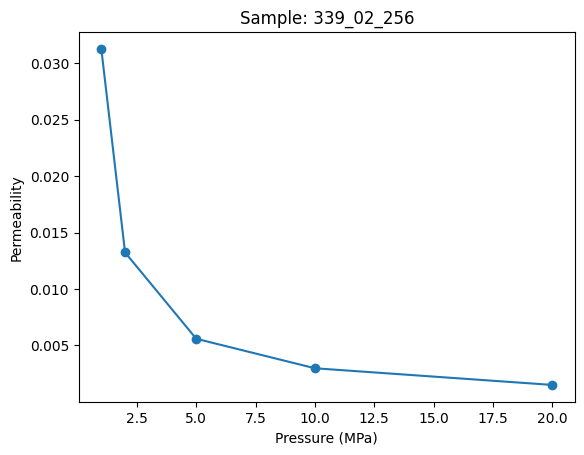

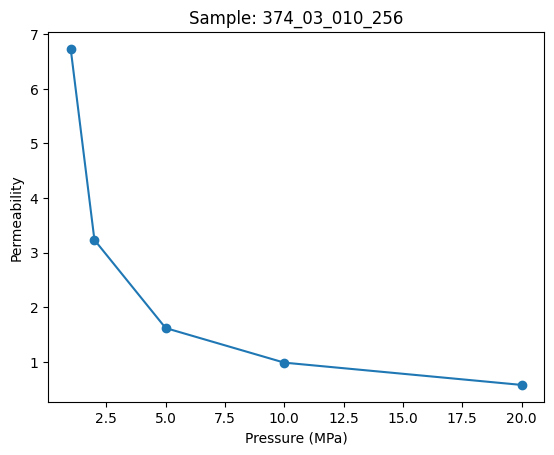

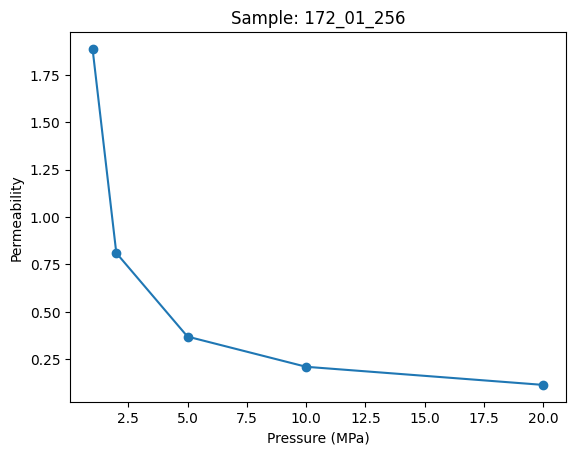

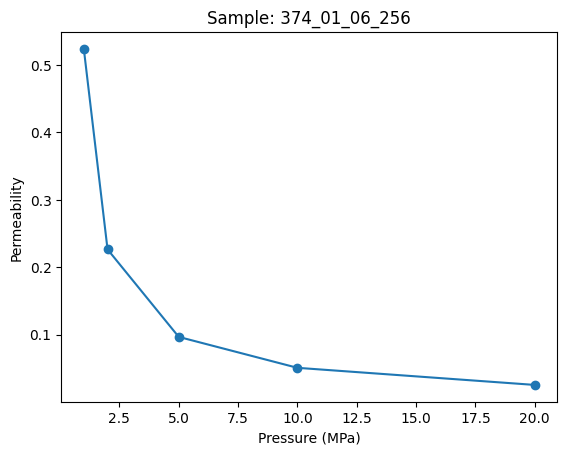

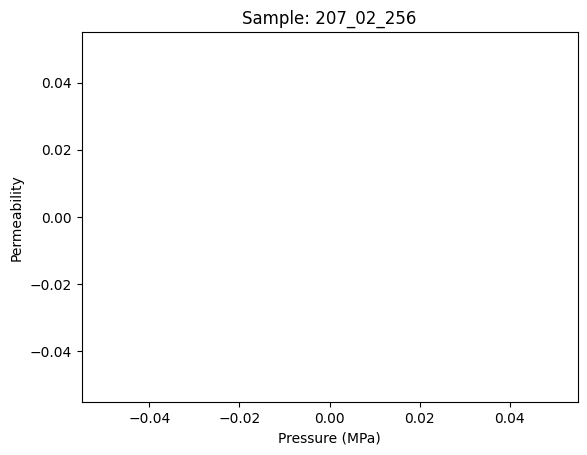

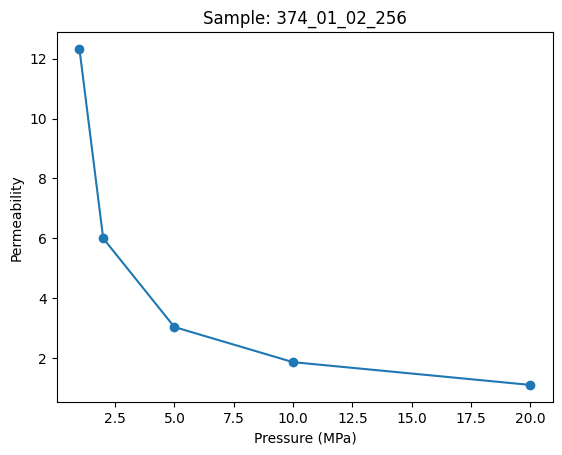

In [7]:
# @title Отрисовка зависимости
import matplotlib.pyplot as plt

for _, i in df.sample(6).iterrows():
  perms = i[pressure_cols].values.astype(float)
  plt.plot(pressure_values, perms, 'o-')
  plt.title(f"Sample: {i['sample']}")
  plt.xlabel("Pressure (MPa)")
  plt.ylabel("Permeability")
  plt.show()

In [8]:
# @title Заполним наны благодаря такой зависимости

def fill_permeability_gaps(df, visualize=True, n_plots=4, random_state=42, fill_lbm=True, lbm_factor=1e-12):
    """
    Заполняет пропуски в значениях проницаемости.
    - Удаляет образцы, где полностью отсутствуют данные (все колонки NaN).
    - Если известна только одна точка – заполняет все пропуски этим значением.
    - Если известны 2+ точки и есть положительные – подгоняет степенную зависимость.
    - При неудаче подгонки заполняет средним известных.
    - Отрицательные значения заменяются на NaN (они не должны были остаться после чистки, но на всякий случай).
    """
    pressures = np.array([1, 2, 5, 10, 20], dtype=float)
    perm_cols = [f'perm_{int(p)}MPa' for p in pressures]

    # 1. Удаляем строки, где вообще нет данных по проницаемостям
    mask_all_nan = df[perm_cols].isna().all(axis=1)
    df = df[~mask_all_nan].copy()
    if mask_all_nan.sum() > 0:
        print(f"Удалено полностью пустых образцов: {mask_all_nan.sum()}")

    df_filled = df.copy()
    samples_with_fills = []

    def power_law(P, a, b):
        return a * np.power(P, b)

    for idx, row in df_filled.iterrows():
        values = pd.to_numeric(row[perm_cols], errors='coerce').to_numpy(dtype=float)
        # Отрицательные и нулевые превращаем в NaN, чтобы не ломали подгонку
        values = np.where(values <= 0, np.nan, values)
        valid_mask = ~np.isnan(values)
        P_valid = pressures[valid_mask]
        k_valid = values[valid_mask]
        n_valid = len(P_valid)

        # Если после замены отрицательных на NaN не осталось данных – пропускаем
        if n_valid == 0:
            continue

        had_fill = False

        if n_valid == 1:
            fill_value = k_valid[0]
            for i, col in enumerate(perm_cols):
                if pd.isna(row[col]) or row[col] <= 0:  # исходный NaN или отрицательный
                    df_filled.at[idx, col] = fill_value
                    had_fill = True
        else:
            # Подгонка по положительным значениям (отрицательных уже нет после замены)
            try:
                logP = np.log(P_valid)
                logK = np.log(k_valid)
                coeffs = np.polyfit(logP, logK, 1)
                a = np.exp(coeffs[1])
                b = coeffs[0]
                k_pred = power_law(pressures, a, b)

                for i, col in enumerate(perm_cols):
                    if pd.isna(row[col]) or row[col] <= 0:
                        df_filled.at[idx, col] = k_pred[i]
                        had_fill = True
            except Exception:
                mean_val = k_valid.mean()
                for i, col in enumerate(perm_cols):
                    if pd.isna(row[col]) or row[col] <= 0:
                        df_filled.at[idx, col] = mean_val
                        had_fill = True

        if had_fill:
            samples_with_fills.append(idx)

    # Заполняем perm_LBM
    if fill_lbm and 'perm_LBM' in df_filled.columns:
        for idx, row in df_filled.iterrows():
            if pd.isna(row['perm_LBM']):
                perm_20 = df_filled.at[idx, 'perm_20MPa']
                if not pd.isna(perm_20):
                    df_filled.at[idx, 'perm_LBM'] = perm_20 * lbm_factor

    if visualize and samples_with_fills:
        np.random.seed(random_state)
        selected = np.random.choice(samples_with_fills,
                                    size=min(n_plots, len(samples_with_fills)),
                                    replace=False)

        for idx in selected:
            row_original = df.loc[idx]   # до заполнения (уже без полностью пустых)
            row_filled = df_filled.loc[idx]

            orig_vals = pd.to_numeric(row_original[perm_cols], errors='coerce').to_numpy(dtype=float)
            mask_known = ~np.isnan(orig_vals) & (orig_vals > 0)
            P_known = pressures[mask_known]
            k_known = orig_vals[mask_known]

            filled_vals = row_filled[perm_cols].to_numpy(dtype=float)
            mask_filled = np.isnan(orig_vals) | (orig_vals <= 0)
            P_filled = pressures[mask_filled]
            k_filled = filled_vals[mask_filled]

            plt.figure(figsize=(10, 5))
            plt.plot(P_known, k_known, 'o', color='blue', markersize=8, label='Исходные')
            if len(P_filled) > 0:
                plt.plot(P_filled, k_filled, 's', color='red', markersize=8, label='Заполненные')
            plt.title(f"Образец: {row_original['sample']}")
            plt.xlabel("Эффективное давление, МПа")
            plt.ylabel("Проницаемость")
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.legend()
            plt.show()

    print(f"Обработано образцов: {len(df_filled)}. Заполнены пропуски в {len(samples_with_fills)} образцах.")
    return df_filled

filled_df = fill_permeability_gaps(df)

Удалено полностью пустых образцов: 6
Обработано образцов: 127. Заполнены пропуски в 0 образцах.


In [9]:
#@title Пропуски заполнены, обновим датасет
filled_df.isna().sum()

index           0
sample          0
rock_type       0
perm_1MPa       0
perm_2MPa       0
perm_5MPa       0
perm_10MPa      0
perm_20MPa      0
perm_LBM        0
minkowski_Vn    0
minkowski_An    0
minkowski_Jn    0
minkowski_Xn    0
dtype: int64

In [10]:
# @title Создание итогового датасета

filled_df.to_csv("dataset_combined.csv", index=False)
print(f"Обновлённый файл dataset_combined.csv сохранён.")

csv_dir = "data/csv"
pressures = ['1', '2', '5', '10', '20', 'LBM']
col_map = {
    '1': 'perm_1MPa',
    '2': 'perm_2MPa',
    '5': 'perm_5MPa',
    '10': 'perm_10MPa',
    '20': 'perm_20MPa',
    'LBM': 'perm_LBM'
}

for _, row in filled_df.iterrows():
    sample_name = row['sample']
    csv_file = os.path.join(csv_dir, f"{sample_name}.csv")

    data = []
    for p in pressures:
        col = col_map[p]
        if col in row.index:
            val = row[col]
            if pd.notna(val):
                data.append({'pressure': p, 'permeability': val})

    if data:
        sample_df = pd.DataFrame(data)
        sample_df.to_csv(csv_file, index=False)
        print(f"Обновлён: {csv_file}")
    else:
        print(f"Пропущен (нет данных): {sample_name}")

print("Все файлы обновлены.")

dataset = PermeabilityDataset()

Обновлённый файл dataset_combined.csv сохранён.
Обновлён: data/csv/10_01_256.csv
Обновлён: data/csv/135_00_256.csv
Обновлён: data/csv/135_02_256.csv
Обновлён: data/csv/135_03_256.csv
Обновлён: data/csv/135_04_256.csv
Обновлён: data/csv/16_01_256.csv
Обновлён: data/csv/16_02_256.csv
Обновлён: data/csv/172_01_256.csv
Обновлён: data/csv/172_02_256.csv
Обновлён: data/csv/172_03_256.csv
Обновлён: data/csv/204_010_256.csv
Обновлён: data/csv/204_011_256.csv
Обновлён: data/csv/204_012_256.csv
Обновлён: data/csv/204_01_256.csv
Обновлён: data/csv/204_02_256.csv
Обновлён: data/csv/204_03_256.csv
Обновлён: data/csv/204_04_256.csv
Обновлён: data/csv/204_05_256.csv
Обновлён: data/csv/204_07_256.csv
Обновлён: data/csv/204_08_256.csv
Обновлён: data/csv/204_09_256.csv
Обновлён: data/csv/207_01_256.csv
Обновлён: data/csv/207_03_256.csv
Обновлён: data/csv/207_04_256.csv
Обновлён: data/csv/276_01_256.csv
Обновлён: data/csv/297_01_256.csv
Обновлён: data/csv/317_010_256.csv
Обновлён: data/csv/317_011_256.cs

In [60]:
#@title Вывод одного элемента для проверки
dataset[1024]

(tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          ...,
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
       

# Фильтрации бинарных рисунков
Функции фильтрации позволяют покрасить пустоты в
 градиент, что в дальнейшем позволит делать градацию серого и считать персистентные гомологии.

## Кастомные функции фильтраций

In [12]:
# @title Height filtration

def apply_height_filtration(data, normal=(0, 0, 1), d=0):
    L = []
    for i in data:
        L.append(apply_height_filtration_one(i, normal, d))
    return np.array(L)


def apply_height_filtration_one(data, normal=(0, 0, 1), d=0):
    shape = data.shape
    # Создаем сетку координат, центрированную относительно центра куба
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    z_c, y_c, x_c = z - (shape[0] // 2 - 1), y - (shape[0] // 2 - 1), x - (shape[0] // 2 - 1)

    # Нормируем вектор нормали
    n = np.array(normal) / np.linalg.norm(normal)

    # Вычисляем расстояние от каждой точки до плоскости
    dist_from_plane = x_c * n[0] + y_c * n[1] + z_c * n[2] - d
    filtration_values = np.abs(dist_from_plane)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)

    return filtration_values

In [13]:
#@title Radial filtration
def apply_radial_filtration(data, p=None):
    L = []
    for i in data:
        L.append(apply_radial_filtration_one(i, p))
    return np.array(L)

def apply_radial_filtration_one(data, p=None):
    shape = data.shape

    if p is None:
        p = (shape[0]//2, shape[1]//2, shape[2]//2)

    # Создаем сетку координат
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]

    # Вычисляем квадраты расстояний от центра p для каждой оси
    dist_sq = (x - p[0])**2 + (y - p[1])**2 + (z - p[2])**2
    filtration_values = np.sqrt(dist_sq)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)

    return filtration_values

In [14]:
# @title Line filtration

def apply_line_filtration(data, p1=(0, 0, 0), p2=(255, 255, 255)):
    L = []
    for i in data:
        L.append(apply_line_filtration_one(i, p1, p2))
    return np.array(L)


def apply_line_filtration_one(data, p1=(0, 0, 0), p2=(255, 255, 255)):
    shape = data.shape
    # Создаем сетку координат
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    p1 = np.array(p1)
    p2 = np.array(p2)

    # Векторы от p1 до всех точек сетки
    dx, dy, dz = x - p1[0], y - p1[1], z - p1[2]

    # Направляющий вектор прямой (p2 - p1) и его норма
    v = p2 - p1
    v_norm_sq = np.sum(v**2) + 1e-9

    # Расстояние от точки до прямой
    cross_x = dy * v[2] - dz * v[1]
    cross_y = dz * v[0] - dx * v[2]
    cross_z = dx * v[1] - dy * v[0]

    filtration_values = np.sqrt((cross_x**2 + cross_y**2 + cross_z**2) / v_norm_sq)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)


    return filtration_values

## Функции визуализации породы
Данные функции позволяют отрисовать изображение породы по трехмерному бинарному массиву данных

In [78]:
# @title visualize

def visualize(data, sample_name='rock_structure_1', substance_name = "rock_1",
              L = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, decimation_factor=0.9, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape

    # Создаем сетку
    grid = pv.ImageData(dimensions=shape, spacing=(1, 1, 1), origin=(0, 0, 0))
    grid.point_data["values"] = data_np.flatten(order="F")

    # Генерация изоповерхности (максимальное количество полигонов на входе)
    surface_mesh = grid.contour([0.5], scalars="values")

    # Агрессивное уменьшение количества полигонов (Decimation)
    if decimation_factor > 0 and surface_mesh.n_cells > 0:
        surface_mesh = surface_mesh.decimate(decimation_factor)

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Рисуем границы куба
    plotter.add_mesh(surface_mesh, color='grey', lighting=True) ## smooth_shading=True добавлять?
    plotter.add_mesh(pv.Cube(bounds=[0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1]),
                     style='wireframe', color='black', line_width=1, opacity=0.5) # добавляем границы

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L
    plotter.add_title(substance_name, font_size=10)  # название камня

    img_path = f'/tmp/{sample_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del surface_mesh
    del grid

    if T:
      display(Image(img_path))

In [79]:
# @title visualize_color_rock, _pore, _all, _binary

def visualize_color_rock(data, filtration_vol, file_name='rock_structure_colored',
                         L = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, decimation_factor=0.9, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Записываем маску породы и значения фильтрации в данные ячеек (cell_data)
    grid.cell_data["rock_mask"] = data_np.flatten(order="F").astype(np.uint8)
    grid.cell_data["dist_value"] = filt_np.flatten(order="F")

    # Переносим данные из ячеек в точки (point_data), так как алгоритм contour работает с точками
    grid = grid.cell_data_to_point_data()

    # Создаем полигональную сетку (изоповерхность) на границе пора/порода (значение 0.5)
    mesh = grid.contour([0.5], scalars="rock_mask")

    # Уменьшаем количество полигонов для ускорения отрисовки, если задан коэффициент
    if decimation_factor > 0 and mesh.n_cells > 0:
        mesh = mesh.decimate(decimation_factor)

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Добавляем сетку в визуализатор, раскрашивая по значениям фильтрации, убираем шкалу
    if "dist_value" in mesh.point_data:
        plotter.add_mesh(mesh, scalars="dist_value", cmap="jet", lighting=True, show_scalar_bar=False)
    else:
        # Если данные потерялись при децимации, интерполируем их заново
        mesh = mesh.sample(grid)
        plotter.add_mesh(mesh, scalars="dist_value", cmap="jet", lighting=True, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(pv.Cube(bounds=[0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1]),
                     style='wireframe', color='black', opacity=0.5)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del mesh
    del grid

    if T:
      display(Image(img_path))


def visualize_color_pore(data, filtration_vol, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Если порода (data == 0), присваиваем -0.1 для серого цвета
    vis_values = np.where(data_np == 1, filt_np, -0.1)
    grid.cell_data["colors"] = vis_values.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    # Создаем модифицированный jet
    jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
    new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
    custom_cmap = LinearSegmentedColormap.from_list('jet_with_grey', new_colors)

    plotter.add_mesh(faces, scalars="colors", cmap=custom_cmap,
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def visualize_color_all(filtration_vol, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)
    shape = filt_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))


    grid.cell_data["colors"] = filt_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    plotter.add_mesh(faces, scalars="colors", cmap='jet',
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def visualize_color_binary(data, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Если порода (data == 0), присваиваем -0.1 для серого цвета
    grid.cell_data["colors"] = data_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')


    plotter.add_mesh(faces, scalars="colors", cmap=ListedColormap(['#6a6863', 'white']),
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))

In [80]:
# @title Функции отрисовки срезов
def show_slice(data, k=128, axis = 'z', T = True):
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = data.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = data.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = data.squeeze()[:, :, k]

    if not T:
      return slice_2d

    # Визуализация среза
    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=ListedColormap(['#6a6863', 'white'])) #  0-серый (порода), 1-белый (поры)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_pore(data, normalized_grad, k=128, axis = 'z', T = True):
    # Применяем маску: там где порода (data == 0), ставим -0.1 для серого цвета
    vis_volume = np.where(data.squeeze() == 1, normalized_grad.squeeze(), -0.1)

    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d


    # Создаем копию jet, но добавляем цвет #6a6863 для породы
    jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
    new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
    custom_cmap = LinearSegmentedColormap.from_list('custom_jet', new_colors)

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=custom_cmap)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_rock(data, normalized_grad, k=128, axis = 'z', T = True):
    # Применяем маску: там где поры (data == 1), ставим -0.1 для белого цвета
    vis_volume = np.where(data.squeeze() == 0, normalized_grad.squeeze(), -0.1)

    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d

    # Создаем копию jet, но для пор устанавливаем белый цвет
    base_cmap = plt.get_cmap('jet')
    new_colors = base_cmap(np.linspace(0, 1, 256))
    custom_cmap = LinearSegmentedColormap.from_list('custom_jet_rock', new_colors)
    custom_cmap.set_under('white')

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=custom_cmap)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_all(normalized_grad, k=128, axis = 'z', T = True):
    vis_volume = normalized_grad.squeeze()
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap='jet')
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()

In [81]:
# @title show_filtration, show_filtration_small

def show_filtration(data, filt, sample_name='rock_1', substance_name = "rock_1", axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    # Предварительная генерация 3D скриншотов
    data=data.squeeze()
    filt=filt.squeeze()
    visualize(data, sample_name, substance_name, camera_position, False)
    visualize_color_rock(data, filt, f'rock_{sample_name}', camera_position, False)
    visualize_color_pore(data, filt, f'pore_{sample_name}', camera_position, False)

    # Создаем общую фигуру 4x3
    fig = plt.figure(figsize=(18, 24))

    # заголовок
    fig.text(0.15, 0.91, f"Образец: {sample_name}", fontsize=20, va='center')

    # шкала min max
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig.add_axes([0.42, 0.90, 0.53, 0.015])
    cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
    cb.set_label('Filtration values', labelpad=-75, fontsize=18)
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['min', 'max'], fontsize=18)

    # 3D визуализация
    paths = [f'/tmp/{sample_name}.png', f'/tmp/rock_{sample_name}.png', f'/tmp/pore_{sample_name}.png']
    for i, path in enumerate(paths):
        ax = fig.add_subplot(4, 3, i + 1)
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.axis('off')


    for i, k in enumerate(levels):
        row_idx = i + 1

        # Колонка 1: show_slice
        ax_bin = fig.add_subplot(4, 3, row_idx * 3 + 1)
        ax_bin.imshow(data[:, k, :] if axis == 'z' else (data[k, :, :] if axis == 'x' else data[:, :, k]), cmap=ListedColormap(['#6a6863', 'white']))
        ax_bin.axis('off')
        ax_bin.text(-0.05, 0.5, f"{axis} = {k}", transform=ax_bin.transAxes,
                    rotation='vertical', va='center', ha='right', fontsize=16)

        # Колонка 2: show_slice_filtered_rock
        ax_rock = fig.add_subplot(4, 3, row_idx * 3 + 2)
        ax_rock.imshow(filt[:, k, :] if axis == 'z' else (filt[k, :, :] if axis == 'x' else filt[:, :, k]), cmap='jet')
        ax_rock.axis('off')

        # Колонка 3: show_slice_filtered_pore
        ax_pore = fig.add_subplot(4, 3, row_idx * 3 + 3)
        vis_pore = np.where(data == 1, filt, -0.1)
        jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
        new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
        custom_cmap = LinearSegmentedColormap.from_list('custom_jet', new_colors)
        ax_pore.imshow(vis_pore[:, k, :] if axis == 'z' else (vis_pore[k, :, :] if axis == 'x' else vis_pore[:, :, k]), cmap=custom_cmap)
        ax_pore.axis('off')

    # Настраиваем отступы вручную, чтобы убрать пустоту справа
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.05, wspace=0.05, hspace=0.1)
    plt.show()


def show_filtration_small(filt, sample_name='rock_1', substance_name = "rock_1", axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    # Предварительная генерация 3D скриншотов
    filt=filt.squeeze()

    visualize_color_all(filt, f'all_{sample_name}', camera_position, False)

    # Создаем общую фигуру
    fig, ax = plt.subplots(nrows=1, ncols=1 + len(levels), figsize=(10 + len(levels), 18))
    #fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)



    img_all = mpimg.imread(f'/tmp/all_{sample_name}.png')
    ax[0].imshow(img_all)
    ax[0].set_title(f'{substance_name} \n {sample_name}' )
    ax[0].axis('off')

    for i, k in enumerate(levels):
        ax_idx = i + 1
        # Показываем срезы на оставшихся осях
        slice_img = filt[:, k, :] if axis == 'z' else (filt[k, :, :] if axis == 'x' else filt[:, :, k])
        ax[ax_idx].imshow(slice_img, cmap='jet')
        ax[ax_idx].set_title(f"{axis}={k}")
        ax[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

In [82]:
# @title Функции визуализации grayscale

def show_slice_grayscale(grad_data, k=40, axis = 'z', T = True):
    if axis == 'z':
      # Извлекаем срез по оси z
      grayscale_2d = grad_data.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      grayscale_2d = grad_data.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      grayscale_2d = grad_data.squeeze()[:, :, k]

    if not T:
      return grayscale_2d

    plt.figure(figsize=(8, 8))
    plt.imshow(grayscale_2d, cmap='gray') # gray 0 -> черный, 1 -> белый
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def visualize_grayscale_faces(grad_data, sample_name='grayscale_pore_cube_faces',
                         camera_position=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    grad_data_np = np.flip(grad_data.squeeze(), axis=0)
    shape = grad_data_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Добавляем данные в сетку
    grid.cell_data["colors"] = grad_data_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    # Теперь массив 'colors' существует в данных поверхности
    plotter.add_mesh(faces, scalars="colors", cmap='gray',
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = camera_position

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{sample_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def show_grayscale_small(grayscale_filt, sample_name='rock_1', substance_name = "rock_1", filt_name = 'filtration_name', axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    grayscale_filt=grayscale_filt.squeeze()
    visualize_grayscale_faces(grayscale_filt, f'multipl_{small_sample_name}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)


    fig, ax = plt.subplots(ncols= 1 + len(levels), figsize=(10 + len(levels), 18))

    ax[0].imshow(mpimg.imread(f'/tmp/multipl_{small_sample_name}.png'))
    ax[0].set_title(filt_name)
    ax[0].axis('off')

    for i, k in enumerate(levels):
          ax_idx = i + 1
          slice_img = grayscale_filt[:, k, :] if axis == 'z' else (grayscale_filt[k, :, :] if axis == 'x' else grayscale_filt[:, :, k])
          ax[ax_idx].imshow(slice_img, cmap='gray')
          ax[ax_idx].set_title(f"{axis}={k}")
          ax[ax_idx].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=-0.43)
    plt.show()

## Пример визуализации фильтраций (опционально)

In [84]:
# @title Объявление кастомных фильтраций и фильтраций из библиотеки giotto-tda
n = 1000
vol_tensor, target, sample_name = dataset[n]
data = vol_tensor.squeeze().numpy().astype(np.uint8)


#HeightFiltration
HF = HeightFiltration(direction=np.array([0, 1, 1])) # [z, x, y]
height_filt_gt= HF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#RadialFiltration
RF = RadialFiltration(np.array([127, 127, 127])) # [z, x, y]
radial_filt_gt = RF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#DensityFiltration
DeF = DensityFiltration()
density_filt_gt= DeF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#DilationFiltration
DiF = DilationFiltration()
dilation_filt_gt= DiF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#ErosionFiltration
EF = ErosionFiltration()
erosion_filt_gt= EF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#SignedDistanceFiltration
SDF = SignedDistanceFiltration()
signed_distence_filt_gt = SDF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


# Кастомные фильтрации
height_filt = apply_height_filtration(data[np.newaxis, :, :, :], normal=(1, 1, 1), d=100).astype(np.float32)
line_filt = apply_line_filtration(data[np.newaxis, :, :, :], (127, 127, 127), (255, 255, 255)).astype(np.float32)
radial_filt = apply_radial_filtration(data[np.newaxis, :, :, :], (127, 127, 127)).astype(np.float32)

KeyboardInterrupt: 

Имя файла structure_868, размер (256, 256, 256)
Пористость породы 0.27306437492370605
tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.3935e-23])


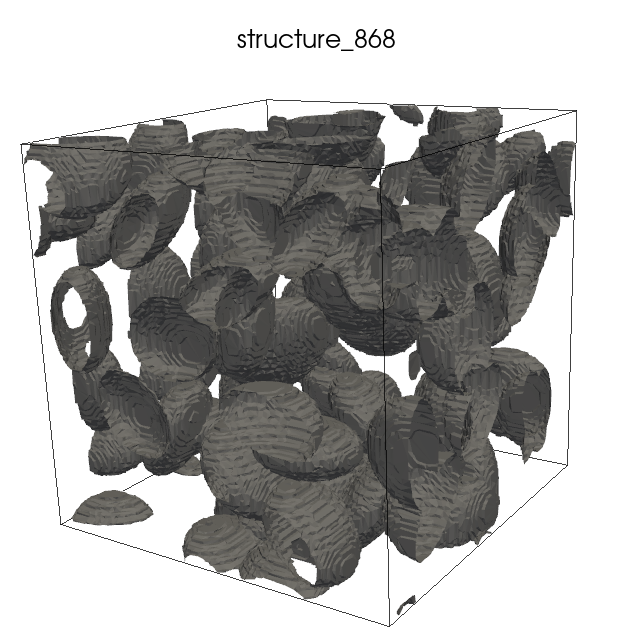

Форма входных данных: (1, 256, 256, 256)


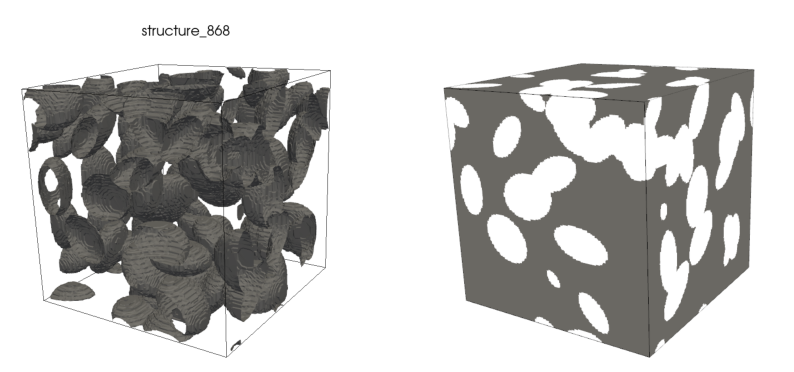

Height Filtration giotto-tda
min: 0.0, max: 361.62445068359375


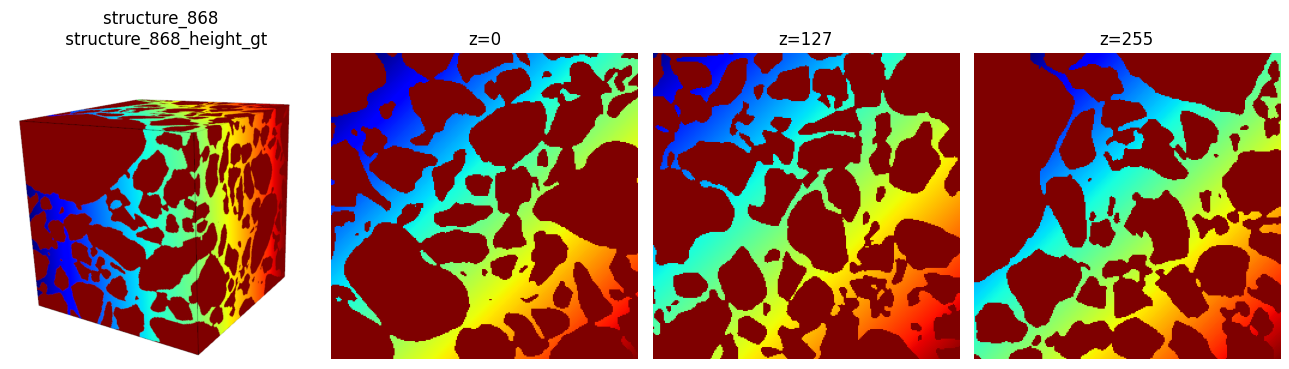

Radial Filtration giotto-tda
min: 4.690415859222412, max: 222.70249938964844


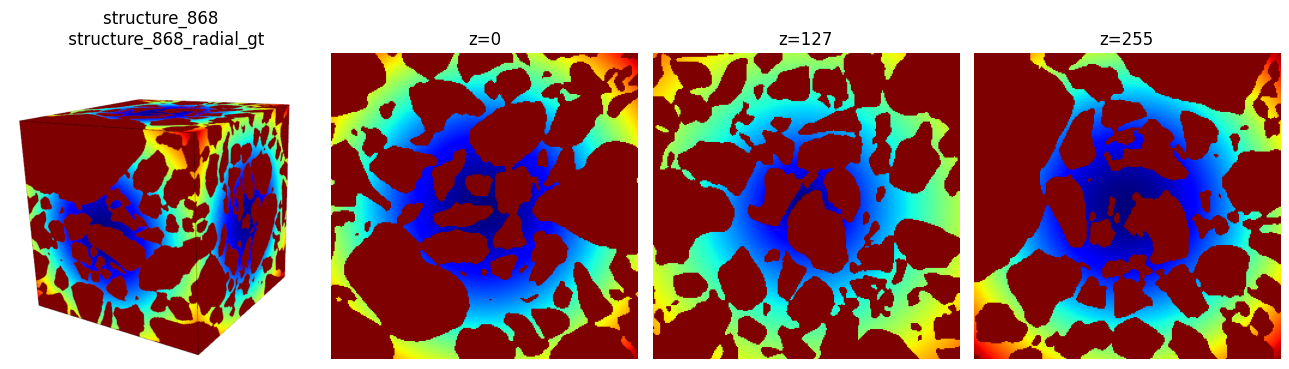

Density Filtration giotto-tda
min: 0.0, max: 123.0


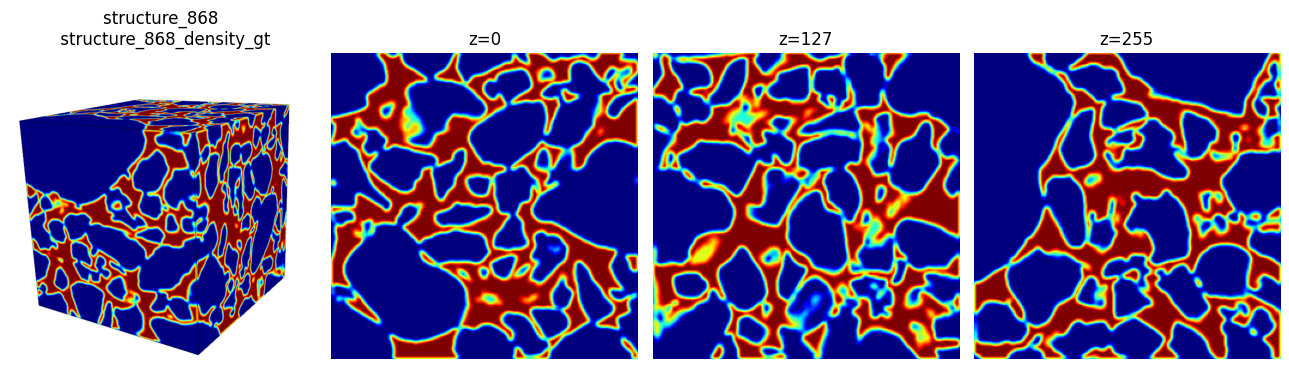

Dilation Filtration giotto-tda
min: 0.0, max: 84.0


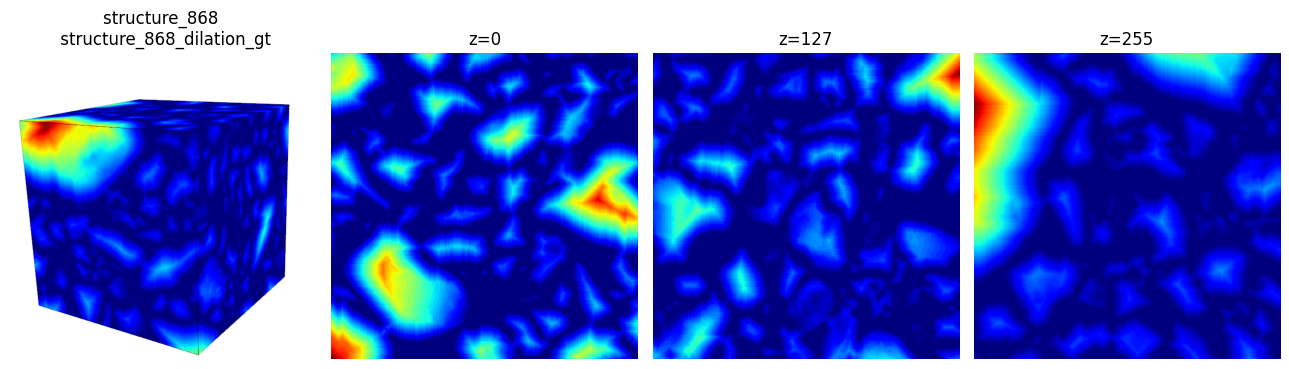

Erosion Filtration giotto-tda
min: 0.0, max: 20.0


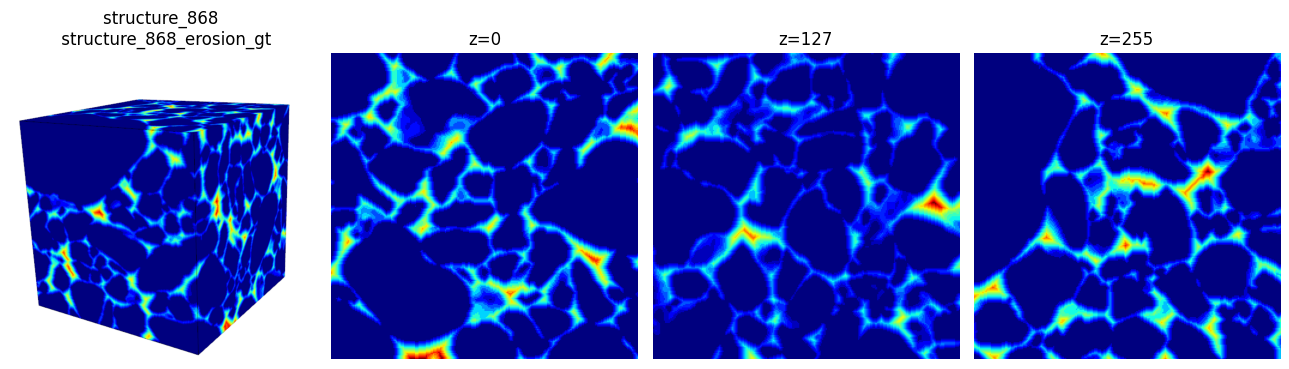

Signed Distence Filtration giotto-tda


NameError: name 'signed_distence_filt_gt' is not defined

In [91]:
#@title Визуализация фильтраций

# сначала визуализируем саму породу
print(f'Имя файла {sample_name}, размер {data.shape}')
print(f'Пористость породы {int(np.sum(data)) / 256**3}') # 1 - поры, 0 - породы
print(target)
visualize(data, sample_name, dataset.get_rock_type(sample_name))


print(f"Форма входных данных: {data[np.newaxis, :, :, :].shape}")

fig, ax = plt.subplots(ncols=2, figsize=(10, 10))

visualize(data, sample_name, dataset.get_rock_type(sample_name), L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T=False)
visualize_color_binary(data, f'binary_{sample_name}', [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], False)

img = mpimg.imread(f'/tmp/{sample_name}.png')
ax[0].imshow(img)
ax[0].axis('off')

img_bin = mpimg.imread(f'/tmp/binary_{sample_name}.png')
ax[1].imshow(img_bin)
ax[1].axis('off')

plt.show()

# Отображаем результат
print("Height Filtration giotto-tda")
print(f'min: {height_filt_gt.min()}, max: {height_filt_gt.max()}')
show_filtration_small(height_filt_gt, f"{sample_name}_height_gt", dataset.get_rock_type(sample_name))

print("Radial Filtration giotto-tda")
print(f'min: {radial_filt_gt.min()}, max: {radial_filt_gt.max()}')
show_filtration_small(radial_filt_gt, f"{sample_name}_radial_gt", dataset.get_rock_type(sample_name))

print("Density Filtration giotto-tda")
print(f'min: {density_filt_gt.min()}, max: {density_filt_gt.max()}')
show_filtration_small(density_filt_gt, f"{sample_name}_density_gt", dataset.get_rock_type(sample_name))

print("Dilation Filtration giotto-tda")
print(f'min: {dilation_filt_gt.min()}, max: {dilation_filt_gt.max()}')
show_filtration_small(dilation_filt_gt, f"{sample_name}_dilation_gt", dataset.get_rock_type(sample_name))

print("Erosion Filtration giotto-tda")
print(f'min: {erosion_filt_gt.min()}, max: {erosion_filt_gt.max()}')
show_filtration_small(erosion_filt_gt, f"{sample_name}_erosion_gt", dataset.get_rock_type(sample_name))

print("Signed Distence Filtration giotto-tda")
print(f'min: {signed_distence_filt_gt.min()}, max: {signed_distence_filt_gt.max()}')
show_filtration_small(signed_distence_filt_gt, f"{sample_name}_signed_distence_gt", dataset.get_rock_type(sample_name))

# Визуализация кастомных фильтраций
print("Height Filtration custom")
print(f'min: {height_filt.min()}, max: {height_filt.max()}')
show_filtration_small(height_filt, f"{sample_name}_height", dataset.get_rock_type(sample_name))

print("Line Filtration custom")
print(f'min: {line_filt.min()}, max: {line_filt.max()}')
show_filtration_small(line_filt, f"{sample_name}_line", dataset.get_rock_type(sample_name))

print("Radial Filtration custom")
print(f'min: {radial_filt.min()}, max: {radial_filt.max()}')
show_filtration_small(radial_filt, f"{sample_name}_line", dataset.get_rock_type(sample_name))


(1, 85, 85, 85)
(1, 85, 85, 85)


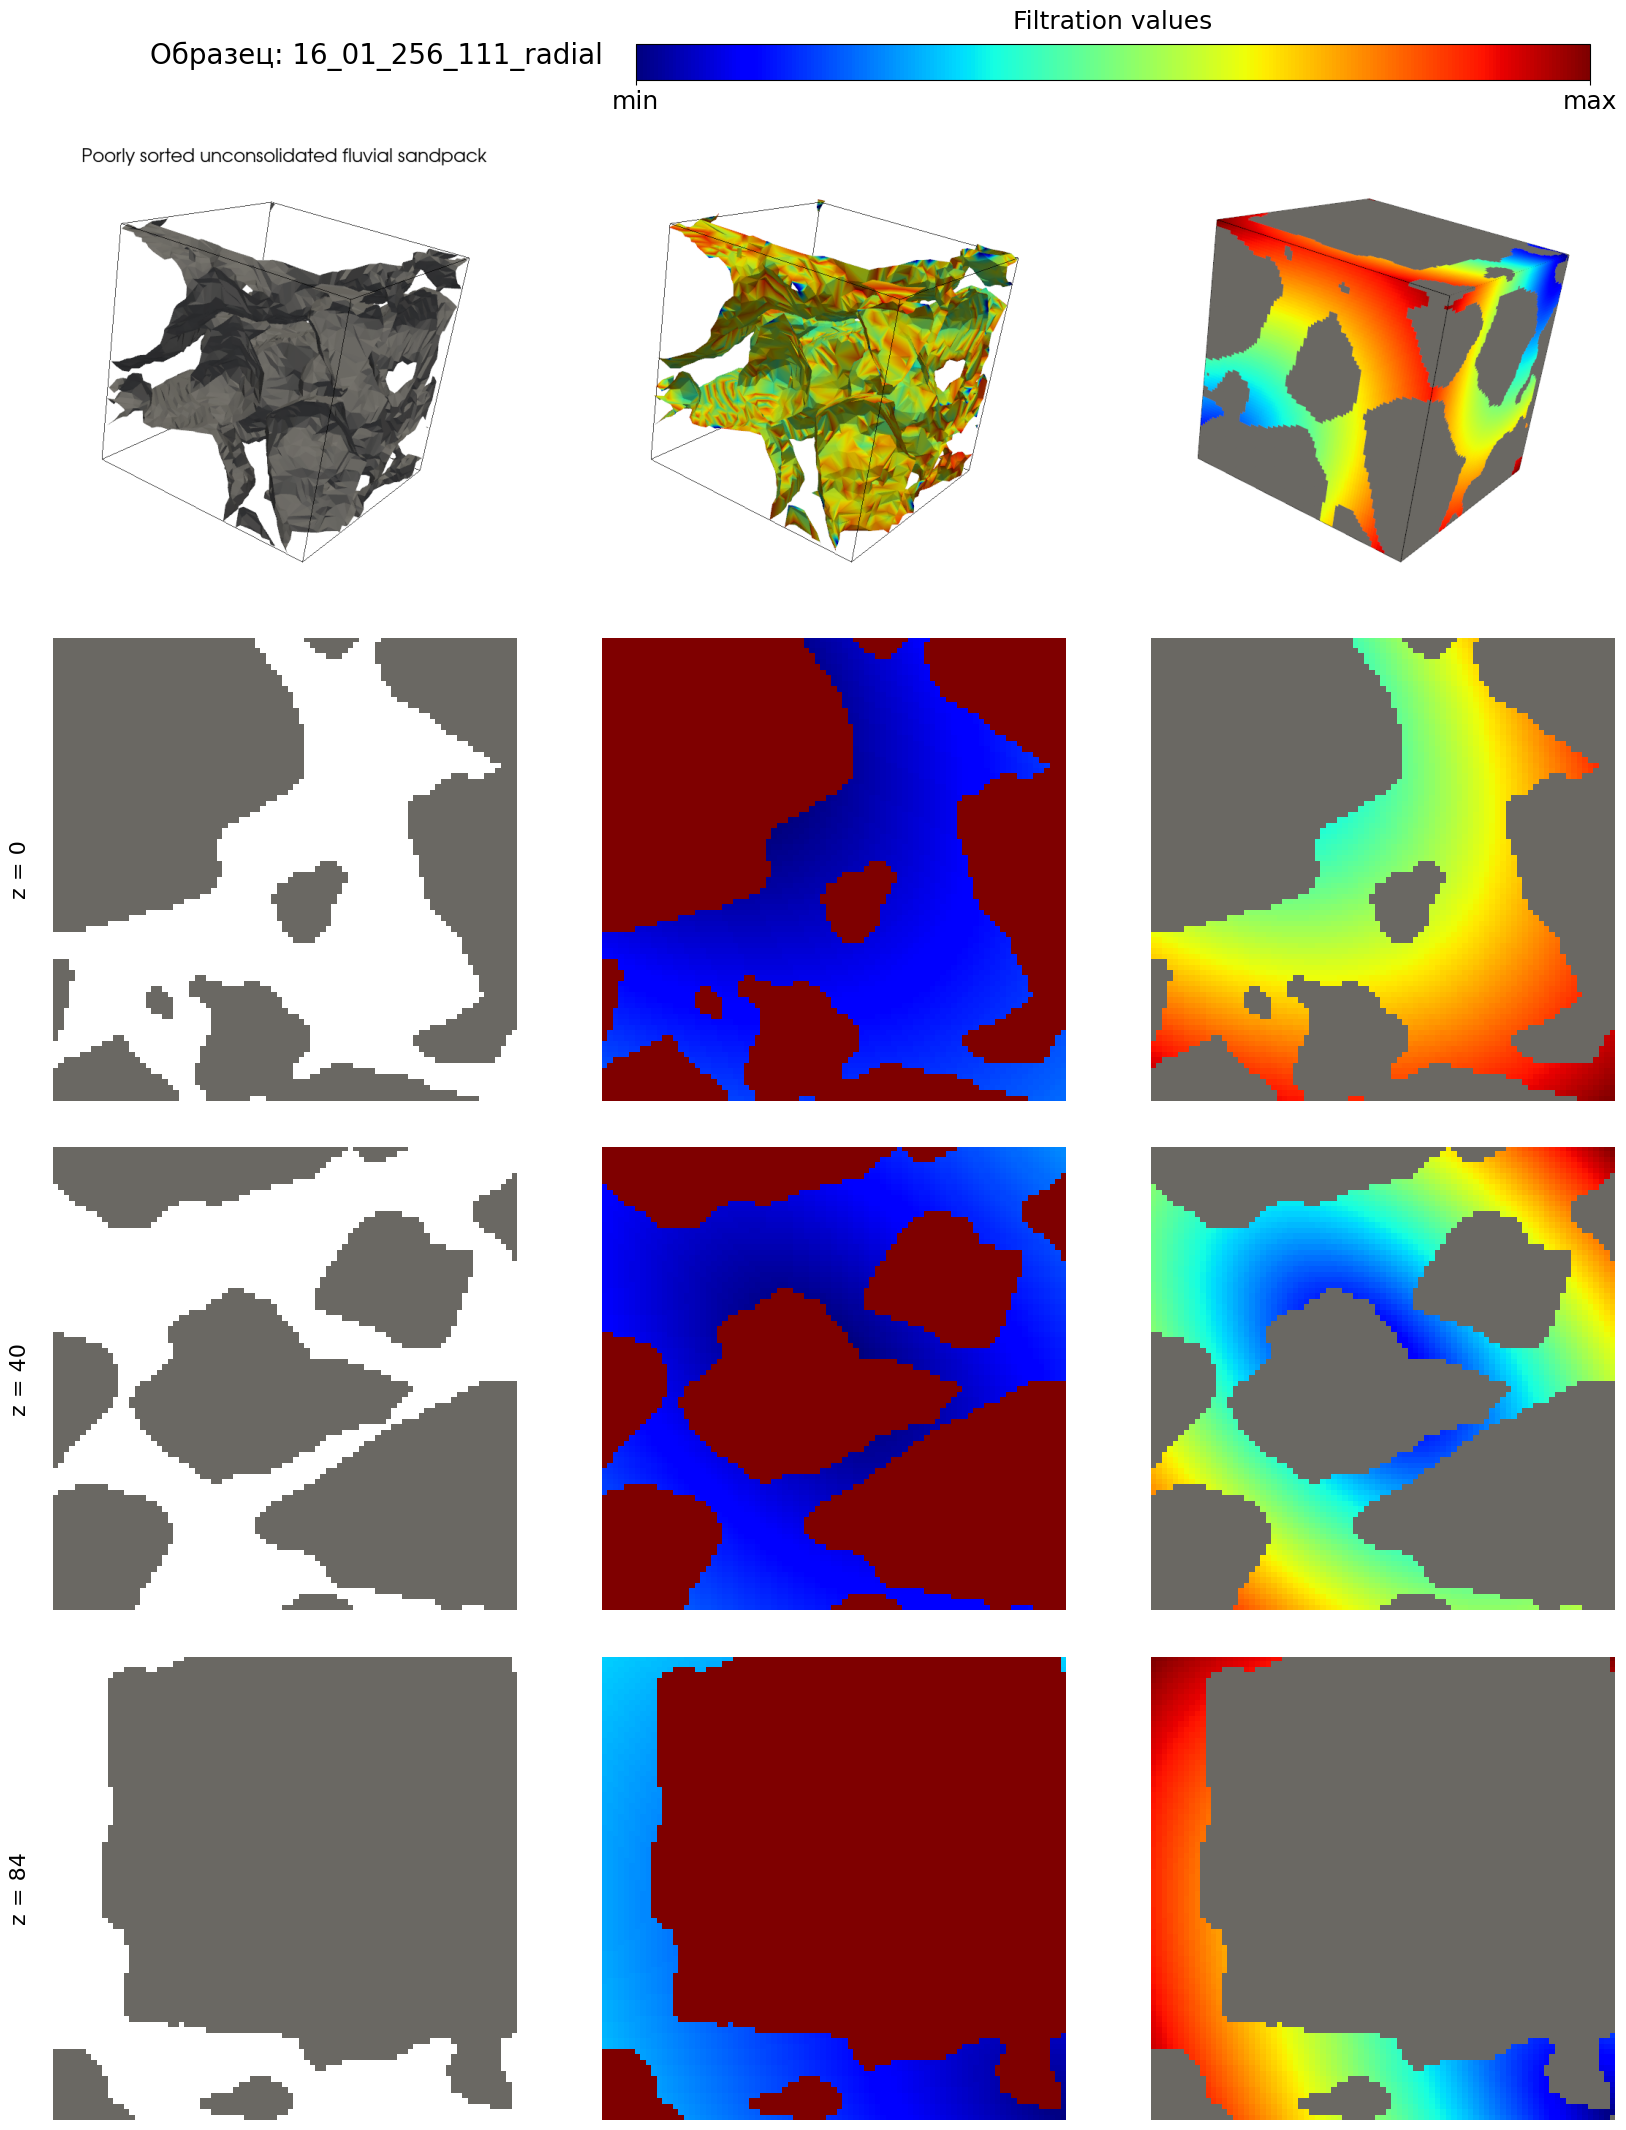

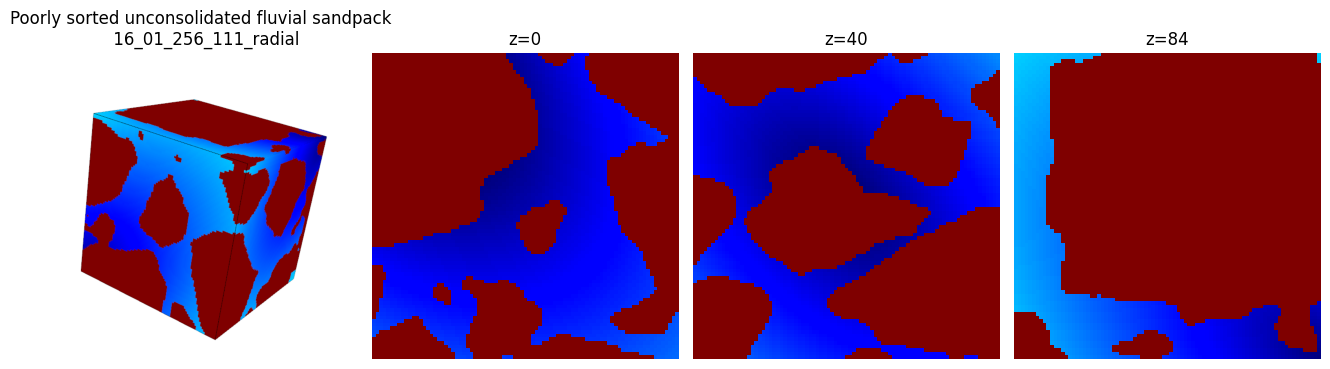

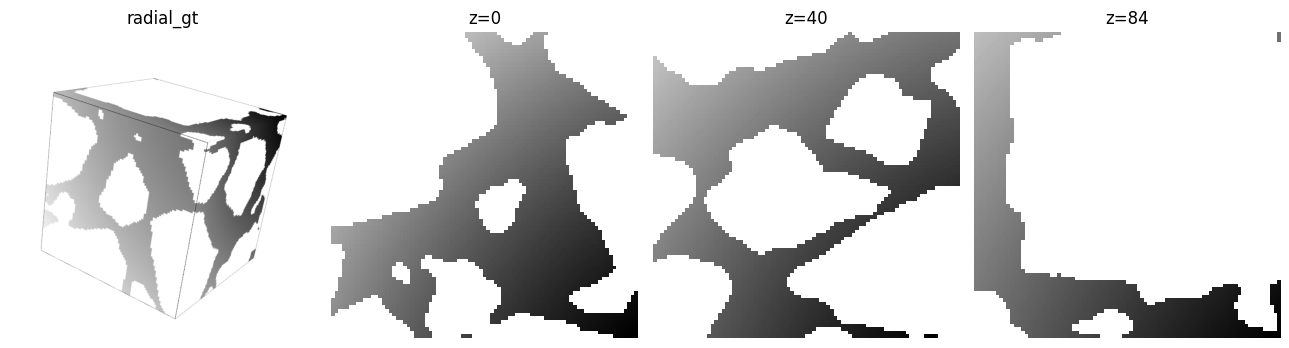

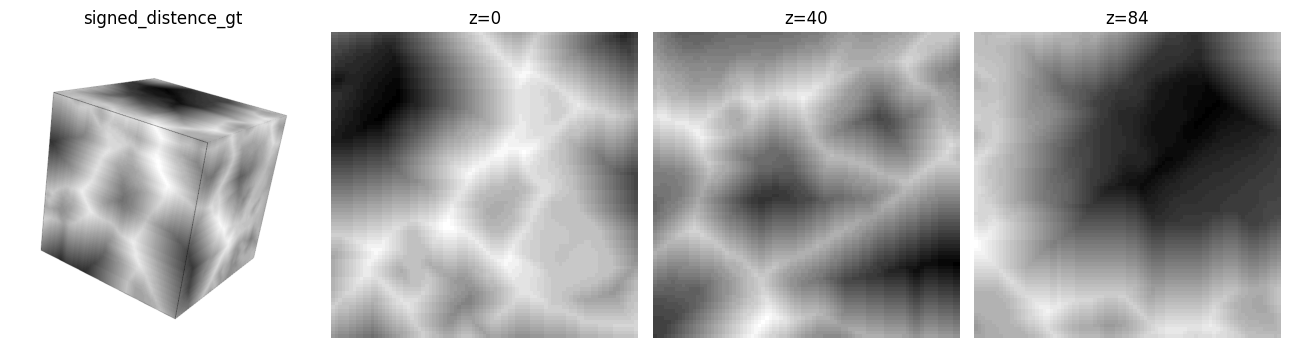

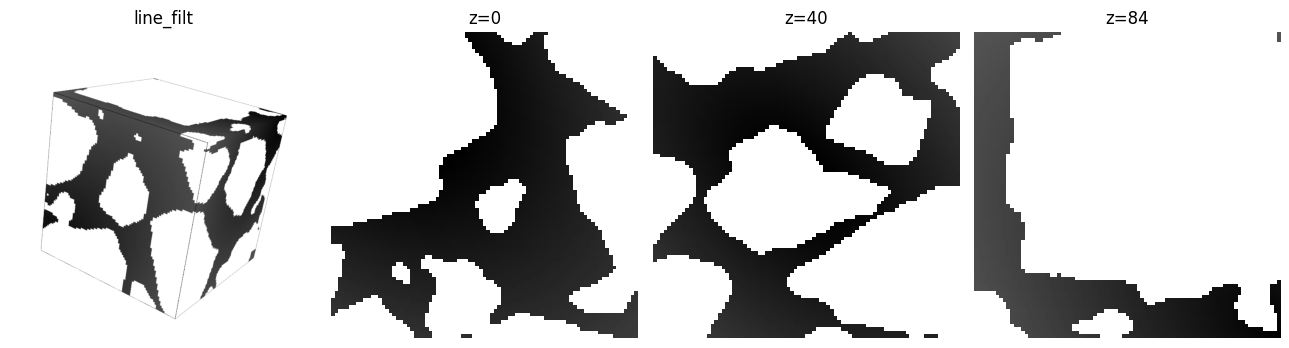

In [ ]:
# @title Пример визуализации фильтраций в сером для маленького кубика со стороной 85

grayscale_filt = line_filt[:, :85, :85, :85] # значения от 0 до 1 #:85, 85:170, 171:256
grayscale_data = 1-vol_tensor.numpy()[:, :85, :85, :85] # 0 - порода, 1 - поры
small_sample_name = f'{sample_name}_111_radial'


# Передаем уровни (levels), которые не превышают размер 85
print(grayscale_filt.shape)
print(grayscale_data.shape)
show_filtration(grayscale_data, grayscale_filt, small_sample_name, dataset.get_rock_type(sample_name), levels=[0, 40, 84], camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])
show_filtration_small(grayscale_filt, small_sample_name, dataset.get_rock_type(sample_name), levels=[0, 40, 84], camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

# меньшие числа соответсвуют более темным точка, болшие - более светлым.
show_grayscale_small(radial_filt_gt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'radial_gt', levels = [0, 40, 84],
                     camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

show_grayscale_small(signed_distence_filt_gt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'signed_distence_gt', levels = [0, 40, 84],
                     camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

show_grayscale_small(line_filt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'line_filt', levels = [0, 40, 84],
                     camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

# Визуализация кубического комплекса
В этом разделе визуализуруем кубические комплексы разными способами

In [ ]:
# @title Функции визуализации кубического комплекса
def show_cubical_complex_slice(img_filtered, k=42, axis = 'z', num_thresholds = 10):
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = img_filtered.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = img_filtered.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = img_filtered.squeeze()[:, :, k]

    v_min = np.min(slice_2d)
    v_max = np.max(slice_2d)
    fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)

    ax[0].imshow(slice_2d, cmap='gray') # gray 0 -> черный, 1 -> белый
    ax[0].set_title(f"{axis} = {k}")
    ax[0].axis('off')

    for i, t in enumerate(np.linspace(v_min, v_max, num_thresholds)): # 20 порогов от 0 до 1
        ax[i+1].axis("off")
        ax[i+1].imshow(slice_2d <= t, cmap='gray_r', vmin=0, vmax=1)
        ax[i+1].set_title(f"{t:.2f}")
    plt.tight_layout()
    plt.show()


def visualize_cubical_complex_faces(img_filtered, num_thresholds = 10, title = 'cubical_complex', title_2 = "filt"):
      v_min = np.min(img_filtered)
      v_max = np.max(img_filtered)
      v_min = v_min + (v_max - v_min) / num_thresholds
      fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)

      visualize_grayscale_faces(img_filtered, f'cubical_complex_pore_{small_sample_name}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)
      ax[0].imshow(mpimg.imread(f'/tmp/{title}.png'))
      ax[0].set_title(title_2, fontsize = 10)
      ax[0].axis('off')

      for i, t in enumerate(np.linspace(v_min, v_max, num_thresholds)):
          vis_values = np.where(img_filtered <= t, 0, 1)
          visualize_grayscale_faces(vis_values, f'{title}_{i+1}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)
          ax[i+1].imshow(mpimg.imread(f'/tmp/{title}_{i+1}.png'))
          ax[i+1].set_title(f"{t:.2f}")
          ax[i+1].axis("off")
      plt.tight_layout()
      plt.show()

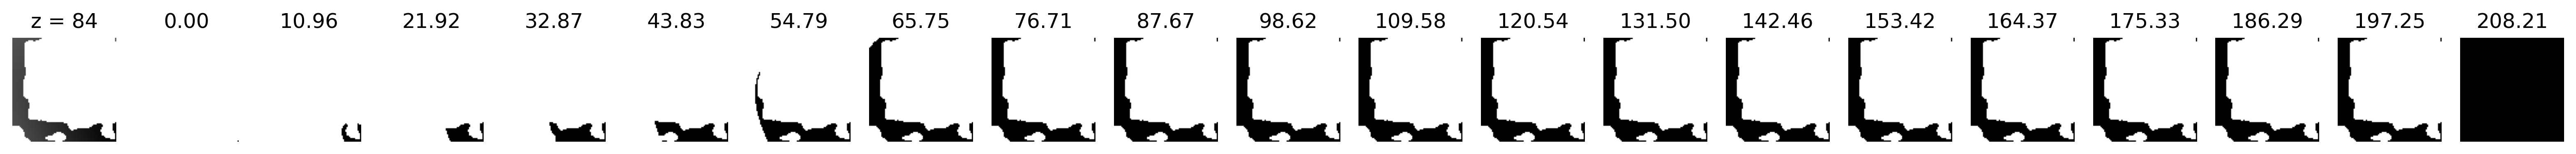

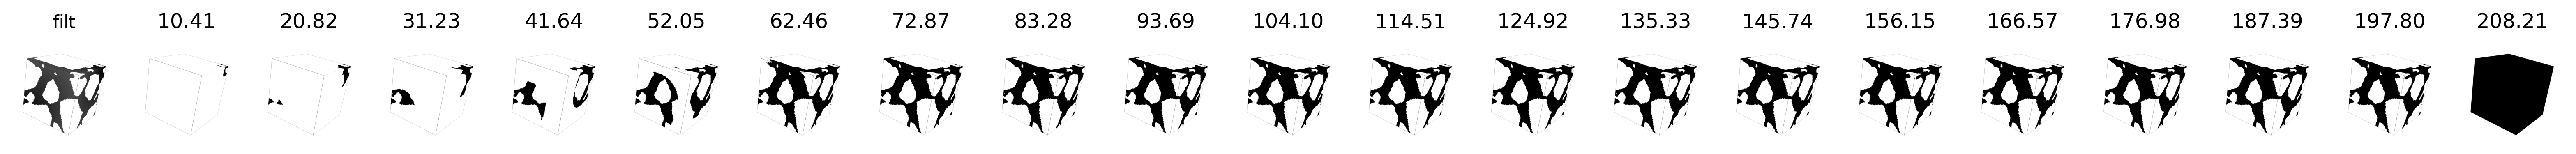

In [ ]:
# @title Пример визуализации кубического комплекса для маленького кубика (опционально)
show_cubical_complex_slice(grayscale_filt[0], 84, num_thresholds = 20)
visualize_cubical_complex_faces(grayscale_filt[0], 20, title = f'cubical_complex_pore_{small_sample_name}')

# Эксперименты с разными методами вычисления ПД

In [ ]:
# @title Вычисление ПД через cripser

def compute_diagrams_cripser(filtration):
    raw = cripser.computePH(filtration, maxdim=2)
    points = raw[:, [1, 2, 0]].copy()
    points[points[:, 1] > 1e300, 1] = np.inf

    return points

In [ ]:
# @title Вычисление ПД через GUDHI

def gudhi_to_array(diagram):
    a = np.array([[birth, death, dim] for (dim, (birth, death)) in diagram])
    return a


def compute_gudhi_dg(data_cube, noise = 0):
    cc = gd.CubicalComplex(dimensions=data_cube.shape, top_dimensional_cells=data_cube.flatten())
    return gudhi_to_array(cc.persistence(min_persistence=noise))

In [ ]:
# @title Визуализация персистентных диграмм для сравнения

grayscale_filt = signed_distence_filt_gt[:, :85, :85, :85]
title = 'signed_distence_gt'

print(grayscale_filt.min(), grayscale_filt.max(), title)

# Расчет через GUDHI
t0 = time.time()
diag_gd = compute_gudhi_dg(grayscale_filt[0])
t1 = time.time()
print(f"Время расчета персистентной диаграммы (GUDHI): {t1-t0:.4f} секунд")

# Визуализация
fig = plot_diagram(diag_gd)
fig.show()

# Расчет через cripser
t0 = time.time()
diag_cripser = compute_diagrams_cripser(grayscale_filt[0])
t1 = time.time()
print(f"Время расчета персистентной диаграммы (cripser): {t1-t0:.4f} секунд")

# Визуализация
fig = plot_diagram(diag_cripser)
fig.show()

# Подсчёт ПД для всего датасета

## Общие функции обработки

In [115]:
# @title Функция вычисления ПД

def compute_diagrams_cripser(filtration):
    raw = cripser.computePH(filtration, maxdim=2)
    points = raw[:, [1, 2, 0]].copy()
    points[points[:, 1] > 1e300, 1] = np.inf

    return points #Возвращает в формате (birth, death, dim)

In [16]:
#@title Служебная функция ограничения выделенной на процесс памяти
def limit_memory(n):
    limit = n * 1024**3
    resource.setrlimit(resource.RLIMIT_AS, (limit, limit))

In [122]:
#@title Функция подсчёта ПД для определенного образца с определенной фильтрацией
def process_sample(filt_name, sample_name, sample_path, output_dir, n):
    limit_memory(n)
    output_path = os.path.join(output_dir, f"{sample_name}_{filt_name}_pd.pkl")

    if os.path.exists(output_path):
        return 0

    cube = np.load(sample_path)
    grayscale = ALL_FILTRATIONS[filt_name](cube)
    points = compute_diagrams_cripser(grayscale)


    with open(output_path, 'wb') as f:
        pickle.dump({
            'sample': sample_name,
            'filtration': filt_name,
            'diagrams': points
        }, f)

    del cube, grayscale, points
    return 1

In [123]:
#@title Функция подсчёта ПД для всего датасета
def process_dataset(filt, ds, input_dir, output_dir, n_memory, n_processes):
  tasks = [
    (filt_name, name, os.path.join(input_dir, f"{name}.npy"), output_dir, n_memory)
    for _, _, name in ds
    for filt_name in filt
  ]
  with tqdm(total=len(tasks), desc="Вычисление ПД", unit="задача") as pbar:
    for _ in Parallel(n_jobs=n_processes)(delayed(process_sample)(*task) for task in tasks):
         pbar.update(1)

In [124]:
#@title Функция создания архива для выгрузки данных на внешний носитель

def create_zip(source_dir, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, filenames in os.walk(source_dir):
            for filename in filenames:
                file_path = os.path.join(root, filename)
                arcname = os.path.relpath(file_path, os.path.dirname(source_dir))
                zipf.write(file_path, arcname)

    print(f"Архив создан: {output_zip}")
    print(f"Размер: {os.path.getsize(output_zip) / 1024**2:.1f} MB")

In [152]:
# @title Функция отрисовки ПД

def plot_pd_from_file(pkl_path, min_persistence=0.01, max_points=None, figsize=(15, 5)):
    """
    Отображает H0, H1, H2 из одного .pkl файла.
    Параметры:
        pkl_path : str
        min_persistence : float
        max_points : int или None – если указано, показывает только top‑max_points
                      наиболее персистентных точек по всей диаграмме (глобально)
        figsize : tuple
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

    points = data['diagrams']
    sample = data.get('sample', '')
    filtration = data.get('filtration', '')

    # Перестановка, теперь (dim, birth, death)
    points = points[:, [2, 0, 1]]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    colors = ['#ef553b', '#00cc96', '#ab63fa']
    dim_names = ['H0', 'H1', 'H2']

    birth = points[:, 1]
    death = points[:, 2]
    # Временно заменяем inf для сортировки
    death_for_sort = np.where(np.isinf(death), 1e10, death)
    pers_all = death_for_sort - birth
    valid_all = (pers_all >= min_persistence) & np.isfinite(birth) & np.isfinite(death)

    # Глобальный отбор top‑max_points
    if max_points is not None and valid_all.sum() > max_points:
        valid_indices = np.where(valid_all)[0]
        sorted_idx = valid_indices[np.argsort(pers_all[valid_all])[::-1]]
        keep_idx = sorted_idx[:max_points]
        global_mask = np.zeros(len(points), dtype=bool)
        global_mask[keep_idx] = True
    else:
        global_mask = valid_all

    # Безопасный максимум для осей (среди отображаемых точек)
    show_birth = birth[global_mask]
    show_death = death[global_mask]
    finite_show = np.isfinite(show_birth) & np.isfinite(show_death)
    if finite_show.any():
        gmax = max(show_birth[finite_show].max(), show_death[finite_show].max()) * 1.05
    else:
        gmax = 1.0

    for dim in range(3):
        ax = axes[dim]
        dim_mask = points[:, 0] == dim
        final_mask = dim_mask & global_mask

        b = birth[final_mask]
        d = death[final_mask]
        d_plot = np.where(np.isinf(d), gmax * 1.1, d)

        if len(b) > 0:
            ax.scatter(b, d_plot, c=colors[dim], alpha=0.6, s=10,
                      edgecolors='white', linewidth=0.3)

        ax.plot([0, gmax * 1.1], [0, gmax * 1.1], 'k--', alpha=0.3, lw=0.8)
        ax.set_xlim(0, gmax * 1.1)
        ax.set_ylim(0, gmax * 1.2)
        ax.set_xlabel('Birth')
        ax.set_ylabel('Death')
        ax.set_title(f'{dim_names[dim]} ({len(b)})')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

    title = f'{sample} | {filtration}'
    if max_points is not None:
        title += f' (global top {max_points} points)'
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

## Создание словарей всех фильтраций


In [117]:
# @title Словарь всех конфигураций радиальных фильтраций (27 штук)

FILTRATIONS_RADIAL = {}

# 3×3×3 = 27 радиальных фильтраций
for i in range(3):
    for j in range(3):
        for k in range(3):
            name = f'radial_{i}_{j}_{k}'
            FILTRATIONS_RADIAL[name] = (
                lambda data, i=i, j=j, k=k: apply_radial_filtration_one(
                    data,
                    p=(
                        data.shape[0] // 4 * (i + 1),
                        data.shape[1] // 4 * (j + 1),
                        data.shape[2] // 4 * (k + 1)
                    )
                )
            )

In [118]:
# @title Словарь всех конфигураций линейных фильтраций (36 штук)

FILTRATIONS_LINE = {}

# ---------- 1. Осевые фильтрации (12 штук) ----------
axial_params = [
    ('X1', 0.5, 0.25, 0.25), ('X2', 0.5, 0.25, 0.75), ('X3', 0.5, 0.75, 0.25), ('X4', 0.5, 0.75, 0.75),
    ('Y1', 0.25, 0.5, 0.25), ('Y2', 0.25, 0.5, 0.75), ('Y3', 0.75, 0.5, 0.25), ('Y4', 0.75, 0.5, 0.75),
    ('Z1', 0.25, 0.25, 0.5), ('Z2', 0.25, 0.75, 0.5), ('Z3', 0.75, 0.25, 0.5), ('Z4', 0.75, 0.75, 0.5),
]

for name, rx, ry, rz in axial_params:
    if 'X' in name:
        v = (1, 0, 0)
    elif 'Y' in name:
        v = (0, 1, 0)
    else:
        v = (0, 0, 1)
    FILTRATIONS_LINE[f'line_{name}'] = (
        lambda data, rx=rx, ry=ry, rz=rz, v=v: apply_line_filtration_one(
            data,
            p1=(int((data.shape[2]-1)*rx), int((data.shape[1]-1)*ry), int((data.shape[0]-1)*rz)),
            p2=(int((data.shape[2]-1)*rx)+v[0], int((data.shape[1]-1)*ry)+v[1], int((data.shape[0]-1)*rz)+v[2])
        )
    )

# ---------- 2. Диагональные фильтрации (24 штуки) ----------
for i in (-1, 1):
    for j in (-1, 1):
        for k in (-1, 1):
            FILTRATIONS_LINE[f'line_diag1_{i}_{j}_{k}'] = (
                lambda data, i=i, j=j, k=k: apply_line_filtration_one(
                    data,
                    p1=((data.shape[2]-1)//2 + (data.shape[2]-1)//4 * i,
                         (data.shape[1]-1)//2 + (data.shape[1]-1)//4 * j,
                         (data.shape[0]-1)//2),
                    p2=((data.shape[2]-1)//2,
                         (data.shape[1]-1)//2,
                         (data.shape[0]-1)//2 + (data.shape[0]-1)//4 * k)
                )
            )
            FILTRATIONS_LINE[f'line_diag2_{i}_{j}_{k}'] = (
                lambda data, i=i, j=j, k=k: apply_line_filtration_one(
                    data,
                    p1=((data.shape[2]-1)//2 + (data.shape[2]-1)//4 * i,
                         (data.shape[1]-1)//2,
                         (data.shape[0]-1)//2 + (data.shape[0]-1)//4 * k),
                    p2=((data.shape[2]-1)//2,
                         (data.shape[1]-1)//2 + (data.shape[1]-1)//4 * j,
                         (data.shape[0]-1)//2)
                )
            )
            FILTRATIONS_LINE[f'line_diag3_{i}_{j}_{k}'] = (
                lambda data, i=i, j=j, k=k: apply_line_filtration_one(
                    data,
                    p1=((data.shape[2]-1)//2,
                         (data.shape[1]-1)//2 + (data.shape[1]-1)//4 * j,
                         (data.shape[0]-1)//2 + (data.shape[0]-1)//4 * k),
                    p2=((data.shape[2]-1)//2 + (data.shape[2]-1)//4 * i,
                         (data.shape[1]-1)//2,
                         (data.shape[0]-1)//2)
                )
            )

In [119]:
# @title Словарь всех конфигураций плоскостных фильтраций (14 штук)


FILTRATIONS_HEIGHT = {}

# ---------- 1. Осевые плоскости (6 штук) ----------
center_x = (256 - 1) // 2
center_y = (256 - 1) // 2
center_z = (256 - 1) // 2
step = 256 // 4
# Нормали и расстояния для каждой из двух плоскостей на ось
axial_planes = [
    ('height_x1', (1, 0, 0), step - center_x),          # x = step
    ('height_x2', (1, 0, 0), 3 * step - center_x),      # x = 3*step
    ('height_y1', (0, 1, 0), step - center_y),          # y = step
    ('height_y2', (0, 1, 0), 3 * step - center_y),      # y = 3*step
    ('height_z1', (0, 0, 1), step - center_z),          # z = step
    ('height_z2', (0, 0, 1), 3 * step - center_z),      # z = 3*step
]

for name, normal, d in axial_planes:
    FILTRATIONS_HEIGHT[name] = (
        lambda data, normal=normal, d=d: apply_height_filtration_one(data, normal, d)
    )

# ---------- 2. Диагональные плоскости (8 штук) ----------
for s_x in (-1, 1):
    for s_y in (-1, 1):
        for s_z in (-1, 1):
            normal = (s_y * s_z, s_x * s_z, s_x * s_y)
            d = s_x * s_y * s_z * step
            signs = f"{'+' if s_x > 0 else '-'}{'+' if s_y > 0 else '-'}{'+' if s_z > 0 else '-'}"
            name = f'height_diag_{signs}'
            FILTRATIONS_HEIGHT[name] = (
                lambda data, normal=normal, d=d: apply_height_filtration_one(data, normal, d)
            )

In [120]:
# @title Словарь всех конфигураций GTDA фильтраций (4 штуки)

def apply_gtda_filtration(data, filtration):
    filtered = filtration.fit_transform(data[np.newaxis, ...])[0]
    M = filtered.max()
    grayscale = np.where(data == 1, filtered, M).astype(np.float64)
    return grayscale


FILTRATIONS_GTDA = {
    'density': lambda data: apply_gtda_filtration(data, DensityFiltration()),
    'dilation': lambda data: apply_gtda_filtration(data, DilationFiltration()),
    'erosion': lambda data: apply_gtda_filtration(data, ErosionFiltration()),
    'signed_distance': lambda data: apply_gtda_filtration(data, SignedDistanceFiltration()),
}


In [121]:
#@title Словарь всех фильтраций
ALL_FILTRATIONS = {}
ALL_FILTRATIONS.update(FILTRATIONS_RADIAL)
ALL_FILTRATIONS.update(FILTRATIONS_LINE)
ALL_FILTRATIONS.update(FILTRATIONS_HEIGHT)
ALL_FILTRATIONS.update(FILTRATIONS_GTDA)
print(f"Всего фильтраций: {len(ALL_FILTRATIONS)}")

Всего фильтраций: 81


## Обработка фильтраций

In [ ]:
#@title Обработка радиальных фильтраций
output_dir = "persistent_diagrams_radial"
input_dir = "data/npy"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_RADIAL, dataset, input_dir, output_dir, n_memory, n_processes)
create_zip(source_dir, output_zip)

In [ ]:
#@title Обработка линейных фильтраций
output_dir = "persistent_diagrams_line"
input_dir = "data/npy"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_LINE, dataset, input_dir, output_dir, n_memory, n_processes)
create_zip(source_dir, output_zip)

In [ ]:
#@title Обработка плоскостных фильтраций
output_dir = "persistent_diagrams_line"
input_dir = "data/npy"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_HEIGHT, dataset, input_dir, output_dir, n_memory, n_processes)
create_zip(source_dir, output_zip)

In [ ]:
#@title Обработка GTDA фильтраций
output_dir = "persistent_diagrams_gtda"
input_dir = "data/npy"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 12
n_processes = 5

real_indices = [i for i, s in enumerate(dataset.samples) if s['type'] != 'synth']
real_dataset = Subset(dataset, real_indices)
process_dataset(FILTRATIONS_GTDA, real_dataset, input_dir, output_dir, n_memory, n_processes)
create_zip(source_dir, output_zip)

Вычисление ПД:   0%|                                                                          | 0/532 [00:00<?, ?задача/s]

## Визуализация конфигруаций кастомных фильтраций

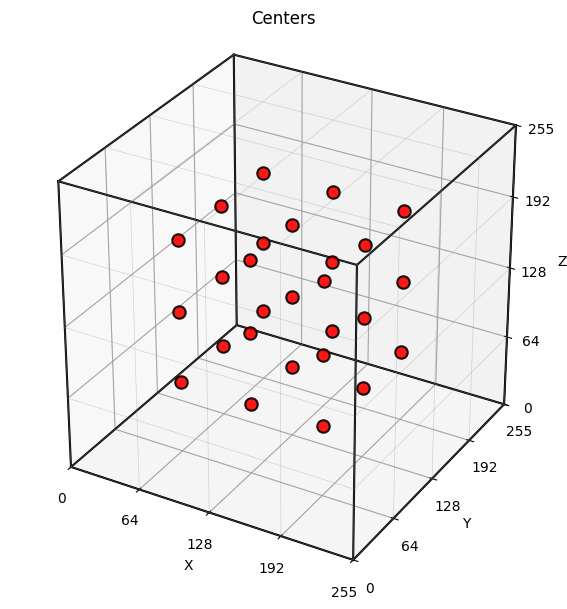

In [ ]:
#@title Визуализация центров радиальных фильтраций

def plot_radial_centers(shape=(256, 256, 256)):
    """
    Визуализация центров 27 радиальных фильтраций (жирные точки)
    и объёмного куба с сеткой на гранях (шаг 64).
    """
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1])

    # Максимальные индексы (0..255)
    Lx, Ly, Lz = shape[2] - 1, shape[1] - 1, shape[0] - 1

    # ---------- Центры радиальных фильтраций (27 точек) ----------
    # i,j,k ∈ {0,1,2} → координаты 64, 128, 192
    centers_x = [shape[2] // 4 * (i + 1) for i in range(3)]
    centers_y = [shape[1] // 4 * (j + 1) for j in range(3)]
    centers_z = [shape[0] // 4 * (k + 1) for k in range(3)]

    for x in centers_x:
        for y in centers_y:
            for z in centers_z:
                ax.scatter(x, y, z,
                           c='red', s=80, edgecolors='black',
                           linewidth=1.5, alpha=0.9)

    # ---------- Каркас куба ----------
    corners = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
                        [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]])
    edges = [(0, 1), (1, 2), (2, 3), (3, 0),
             (4, 5), (5, 6), (6, 7), (7, 4),
             (0, 4), (1, 5), (2, 6), (3, 7)]
    for e1, e2 in edges:
        ax.plot([corners[e1][0] * Lx, corners[e2][0] * Lx],
                [corners[e1][1] * Ly, corners[e2][1] * Ly],
                [corners[e1][2] * Lz, corners[e2][2] * Lz],
                'k-', linewidth=1.5)

    # ---------- Сетка на гранях с шагом 64 ----------
    def get_grid_coords(max_val):
        coords = list(range(0, max_val + 1, 64))
        if coords[-1] != max_val:
            coords.append(max_val)
        return coords

    grid_x = get_grid_coords(Lx)
    grid_y = get_grid_coords(Ly)
    grid_z = get_grid_coords(Lz)

    def draw_grid_face(fixed_coord, axis):
        if axis == 'x':  # плоскость YZ
            for y in grid_y:
                ax.plot([fixed_coord, fixed_coord], [y, y], [0, Lz],
                        color='gray', alpha=0.3, linewidth=0.5)
            for z in grid_z:
                ax.plot([fixed_coord, fixed_coord], [0, Ly], [z, z],
                        color='gray', alpha=0.3, linewidth=0.5)
        elif axis == 'y':  # плоскость XZ
            for x in grid_x:
                ax.plot([x, x], [fixed_coord, fixed_coord], [0, Lz],
                        color='gray', alpha=0.3, linewidth=0.5)
            for z in grid_z:
                ax.plot([0, Lx], [fixed_coord, fixed_coord], [z, z],
                        color='gray', alpha=0.3, linewidth=0.5)
        else:  # 'z' – плоскость XY
            for x in grid_x:
                ax.plot([x, x], [0, Ly], [fixed_coord, fixed_coord],
                        color='gray', alpha=0.3, linewidth=0.5)
            for y in grid_y:
                ax.plot([0, Lx], [y, y], [fixed_coord, fixed_coord],
                        color='gray', alpha=0.3, linewidth=0.5)

    for x in (0, Lx):
        draw_grid_face(x, 'x')
    for y in (0, Ly):
        draw_grid_face(y, 'y')
    for z in (0, Lz):
        draw_grid_face(z, 'z')

    # Деления на осях
    ax.set_xticks(grid_x)
    ax.set_yticks(grid_y)
    ax.set_zticks(grid_z)

    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_zlim(0, Lz)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('Centers')
    plt.tight_layout()
    plt.show()

plot_radial_centers()

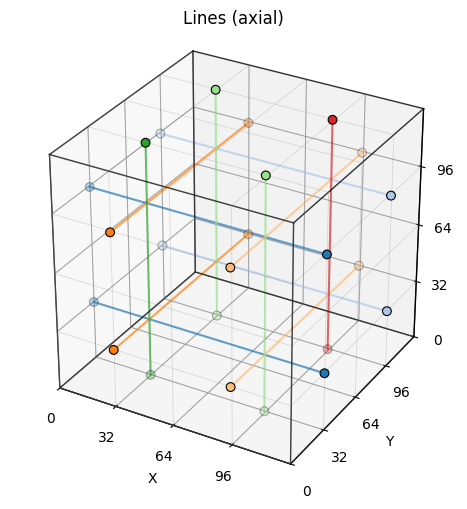

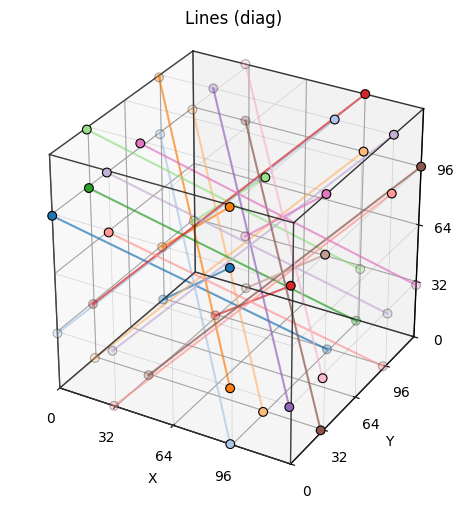

In [ ]:
#@title Визуализация осей линейных фильтраций

def plot_line_through_points(ax, p1, p2, limits, color, cnt):
    """
    Рисует прямую, заданную двумя точками p1 и p2, пересекающую куб,
    и жирные точки на границах.
    limits = (Lx, Ly, Lz) – максимальные координаты (размер-1).
    color – цвет линии и точек.
    cnt – нужен для согласованности, возвращает обновлённый счётчик (не используется).
    """
    Lx, Ly, Lz = limits
    v = np.array(p2, dtype=float) - np.array(p1, dtype=float)
    v_norm = v / np.linalg.norm(v)

    # Найдём параметры t для всех шести граней
    t_candidates = []
    # x = 0
    if v[0] != 0:
        t = (0 - p1[0]) / v[0]
        y = p1[1] + t * v[1]
        z = p1[2] + t * v[2]
        if 0 <= y <= Ly and 0 <= z <= Lz:
            t_candidates.append(t)
    # x = Lx
    if v[0] != 0:
        t = (Lx - p1[0]) / v[0]
        y = p1[1] + t * v[1]
        z = p1[2] + t * v[2]
        if 0 <= y <= Ly and 0 <= z <= Lz:
            t_candidates.append(t)
    # y = 0
    if v[1] != 0:
        t = (0 - p1[1]) / v[1]
        x = p1[0] + t * v[0]
        z = p1[2] + t * v[2]
        if 0 <= x <= Lx and 0 <= z <= Lz:
            t_candidates.append(t)
    # y = Ly
    if v[1] != 0:
        t = (Ly - p1[1]) / v[1]
        x = p1[0] + t * v[0]
        z = p1[2] + t * v[2]
        if 0 <= x <= Lx and 0 <= z <= Lz:
            t_candidates.append(t)
    # z = 0
    if v[2] != 0:
        t = (0 - p1[2]) / v[2]
        x = p1[0] + t * v[0]
        y = p1[1] + t * v[1]
        if 0 <= x <= Lx and 0 <= y <= Ly:
            t_candidates.append(t)
    # z = Lz
    if v[2] != 0:
        t = (Lz - p1[2]) / v[2]
        x = p1[0] + t * v[0]
        y = p1[1] + t * v[1]
        if 0 <= x <= Lx and 0 <= y <= Ly:
            t_candidates.append(t)

    if len(t_candidates) < 2:
        # Прямая не пересекает куб (чего не должно быть), рисуем только отрезок p1-p2
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color=color, alpha=0.7)
        return

    t_min, t_max = min(t_candidates), max(t_candidates)
    pt_enter = np.array(p1) + t_min * v
    pt_exit = np.array(p1) + t_max * v

    # Рисуем линию
    ax.plot([pt_enter[0], pt_exit[0]], [pt_enter[1], pt_exit[1]], [pt_enter[2], pt_exit[2]],
            color=color, alpha=0.7)
    # Жирные точки на границах
    ax.scatter(*zip(pt_enter, pt_exit), c=[color], s=40, edgecolors='black', linewidth=0.8)

def plot_lines_by_type(shape=(128, 128, 128), line_type='axial', grid_step=32):
    """
    Визуализация линий: line_type = 'axial', 'diag' или 'all'.
    """
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1])

    Lx, Ly, Lz = shape[2]-1, shape[1]-1, shape[0]-1
    colors = plt.cm.tab20(np.linspace(0, 1, 36))
    cnt = 0

    # ---------- Осевые линии (12 шт.) ----------
    if line_type in ('axial', 'all'):
        dirs = {'X': (1,0,0), 'Y': (0,1,0), 'Z': (0,0,1)}
        for axis, v in dirs.items():
            if axis == 'X':
                pts = [(0.5,0.25,0.25),(0.5,0.25,0.75),(0.5,0.75,0.25),(0.5,0.75,0.75)]
            elif axis == 'Y':
                pts = [(0.25,0.5,0.25),(0.25,0.5,0.75),(0.75,0.5,0.25),(0.75,0.5,0.75)]
            else:
                pts = [(0.25,0.25,0.5),(0.25,0.75,0.5),(0.75,0.25,0.5),(0.75,0.75,0.5)]
            for (rx, ry, rz) in pts:
                pt = np.array([Lx * rx, Ly * ry, Lz * rz])
                v_arr = np.array(v, dtype=float)
                v_norm = v_arr / np.linalg.norm(v_arr)
                t_vals = []
                for i in range(3):
                    if v_norm[i] != 0:
                        t_vals.append((0 - pt[i]) / v_norm[i])
                        t_vals.append(([Lx, Ly, Lz][i] - pt[i]) / v_norm[i])
                t_min, t_max = min(t_vals), max(t_vals)
                p1 = pt + t_min * v_norm
                p2 = pt + t_max * v_norm
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                        color=colors[cnt], alpha=0.7)
                ax.scatter(*zip(p1, p2), c=[colors[cnt]], s=40, edgecolors='black', linewidth=0.8)
                cnt += 1

    # ---------- Диагональные линии (24 шт.) ----------
    if line_type in ('diag', 'all'):
        for i in (-1, 1):
            for j in (-1, 1):
                for k in (-1, 1):
                    # Набор 1
                    p1 = (Lx // 2 + Lx // 4 * i, Ly // 2 + Ly // 4 * j, Lz // 2)
                    p2 = (Lx // 2, Ly // 2, Lz // 2 + Lz // 4 * k)
                    plot_line_through_points(ax, p1, p2, (Lx, Ly, Lz), colors[cnt], cnt)
                    cnt += 1
                    # Набор 2
                    p1 = (Lx // 2 + Lx // 4 * i, Ly // 2, Lz // 2 + Lz // 4 * k)
                    p2 = (Lx // 2, Ly // 2 + Ly // 4 * j, Lz // 2)
                    plot_line_through_points(ax, p1, p2, (Lx, Ly, Lz), colors[cnt], cnt)
                    cnt += 1
                    # Набор 3
                    p1 = (Lx // 2, Ly // 2 + Ly // 4 * j, Lz // 2 + Lz // 4 * k)
                    p2 = (Lx // 2 + Lx // 4 * i, Ly // 2, Lz // 2)
                    plot_line_through_points(ax, p1, p2, (Lx, Ly, Lz), colors[cnt], cnt)
                    cnt += 1

    # Каркас и сетка
    corners = np.array([[0,0,0],[1,0,0],[1,1,0],[0,1,0],[0,0,1],[1,0,1],[1,1,1],[0,1,1]])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    for e1,e2 in edges:
        ax.plot([corners[e1][0]*Lx, corners[e2][0]*Lx],
                [corners[e1][1]*Ly, corners[e2][1]*Ly],
                [corners[e1][2]*Lz, corners[e2][2]*Lz], 'k-', alpha=0.8, linewidth=1)

    grid_coords = np.arange(0, min(Lx, Ly, Lz)+1, grid_step)
    for z in (0, Lz):
        for x in grid_coords:
            ax.plot([x, x], [0, Ly], [z, z], color='gray', alpha=0.3, linewidth=0.5)
        for y in grid_coords:
            ax.plot([0, Lx], [y, y], [z, z], color='gray', alpha=0.3, linewidth=0.5)
    for y in (0, Ly):
        for x in grid_coords:
            ax.plot([x, x], [y, y], [0, Lz], color='gray', alpha=0.3, linewidth=0.5)
        for z in grid_coords:
            ax.plot([0, Lx], [y, y], [z, z], color='gray', alpha=0.3, linewidth=0.5)
    for x in (0, Lx):
        for y in grid_coords:
            ax.plot([x, x], [y, y], [0, Lz], color='gray', alpha=0.3, linewidth=0.5)
        for z in grid_coords:
            ax.plot([x, x], [0, Ly], [z, z], color='gray', alpha=0.3, linewidth=0.5)

    ax.set_xticks(np.arange(0, Lx+1, grid_step))
    ax.set_yticks(np.arange(0, Ly+1, grid_step))
    ax.set_zticks(np.arange(0, Lz+1, grid_step))
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_zlim(0, Lz)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Lines ({line_type})')
    plt.tight_layout()
    plt.show()

# Пример: раздельная визуализация
plot_lines_by_type(line_type='axial')
plot_lines_by_type(line_type='diag')

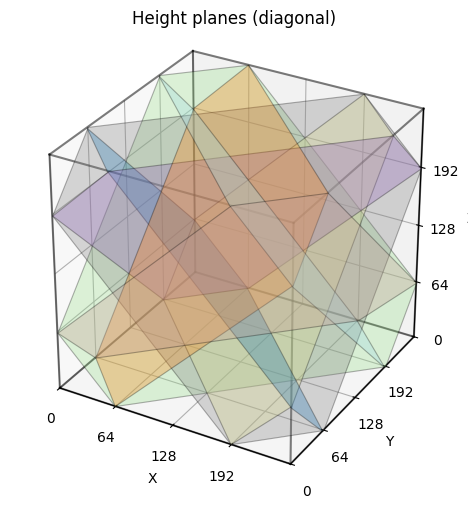

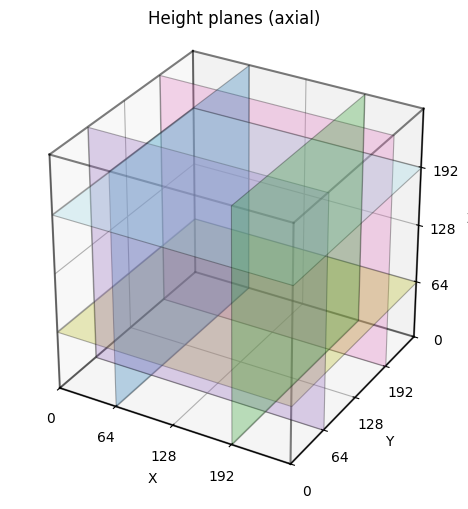

In [ ]:
#@title Визуализация плоскостей для фильтраций

def get_plane_cube_intersection(normal, d, center, cube_min=0, cube_max=255):
    """
    Возвращает вершины выпуклого многоугольника пересечения плоскости
    normal·(x - center) = d с кубом [cube_min, cube_max]^3.
    """
    n = np.asarray(normal)
    rhs = np.dot(n, center) + d

    corners = np.array([[x, y, z]
                        for x in (cube_min, cube_max)
                        for y in (cube_min, cube_max)
                        for z in (cube_min, cube_max)])
    edges = []
    for i in range(8):
        for j in range(i+1, 8):
            diff = corners[i] - corners[j]
            if np.count_nonzero(diff) == 1:
                edges.append((i, j))

    intersection_points = []
    for i, j in edges:
        p1 = corners[i]
        p2 = corners[j]
        d1 = np.dot(n, p1) - rhs
        d2 = np.dot(n, p2) - rhs
        if d1 * d2 < 0:
            t = -d1 / (d2 - d1)
            if 0 <= t <= 1:
                pt = p1 + t * (p2 - p1)
                intersection_points.append(pt)
    if len(intersection_points) < 3:
        return None
    pts = np.array(intersection_points)
    center_mass = pts.mean(axis=0)
    n_unit = n / np.linalg.norm(n)
    if np.abs(n_unit[0]) < 0.9:
        u1 = np.array([1, 0, 0])
    else:
        u1 = np.array([0, 1, 0])
    u1 = u1 - np.dot(u1, n_unit) * n_unit
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(n_unit, u1)
    proj = np.array([[np.dot(pt - center_mass, u1), np.dot(pt - center_mass, u2)] for pt in pts])
    angles = np.arctan2(proj[:,1], proj[:,0])
    sorted_idx = np.argsort(angles)
    return pts[sorted_idx]


def plot_height_planes(shape=(256, 256, 256), plane_type='all'):
    Lx, Ly, Lz = shape[2]-1, shape[1]-1, shape[0]-1
    center = np.array([Lx//2, Ly//2, Lz//2])
    planes = []
    step = shape[0] // 4

    axial = [
        ((1, 0, 0), step - center[0]),
        ((1, 0, 0), 3*step - center[0]),
        ((0, 1, 0), step - center[1]),
        ((0, 1, 0), 3*step - center[1]),
        ((0, 0, 1), step - center[2]),
        ((0, 0, 1), 3*step - center[2]),
    ]
    if plane_type in ('axial', 'all'):
        for normal, d in axial:
            planes.append((np.array(normal, dtype=float), d))

    if plane_type in ('diagonal', 'all'):
        for s_x in (-1, 1):
            for s_y in (-1, 1):
                for s_z in (-1, 1):
                    normal = np.array([s_y * s_z, s_x * s_z, s_x * s_y], dtype=float)
                    d = s_x * s_y * s_z * step
                    planes.append((normal, d))

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1])

    cmap = plt.cm.tab20(np.linspace(0, 1, len(planes)))

    for idx, (n, d) in enumerate(planes):
        pts = get_plane_cube_intersection(n, d, center, 0, Lx)
        if pts is not None and len(pts) >= 3:
            poly = Poly3DCollection([pts], alpha=0.3, facecolor=cmap[idx], edgecolor='k', linewidth=0.8)
            ax.add_collection3d(poly)

    # Каркас куба
    corners = np.array([[0,0,0],[1,0,0],[1,1,0],[0,1,0],[0,0,1],[1,0,1],[1,1,1],[0,1,1]])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    for e1, e2 in edges:
        ax.plot([corners[e1][0]*Lx, corners[e2][0]*Lx],
                [corners[e1][1]*Ly, corners[e2][1]*Ly],
                [corners[e1][2]*Lz, corners[e2][2]*Lz], 'k-', alpha=0.5)

    ax.set_xticks(np.arange(0, Lx+1, 64))
    ax.set_yticks(np.arange(0, Ly+1, 64))
    ax.set_zticks(np.arange(0, Lz+1, 64))
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_zlim(0, Lz)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Height planes ({plane_type})')
    plt.tight_layout()
    plt.show()

plot_height_planes(plane_type='diagonal')
plot_height_planes(plane_type='axial')

## Загрузка ПД с диска и обработка пропусков

In [ ]:
#@title Функция обработки пропусков в ПД

def _process_one_filtration(name, filt_name, filtrations_dict, pd_dir, memory_limit_gb):
    """Обработка одного фильтра для одного образца (используется при параллельном запуске)."""
    if memory_limit_gb is not None:
        limit_bytes = int(memory_limit_gb * 1024**3)
        resource.setrlimit(resource.RLIMIT_AS, (limit_bytes, limit_bytes))

    fpath = os.path.join(pd_dir, f"{name}_{filt_name}_pd.pkl")
    if os.path.exists(fpath):
        return

    # Загружаем куб (каждый воркер читает файл сам, чтобы избежать копирования)
    try:
        cube = np.load(os.path.join("data/npy", f"{name}.npy")).astype(np.uint8)
    except FileNotFoundError:
        # Если файл не найден, пропускаем (такого быть не должно, но на всякий случай)
        return

    filt_func = filtrations_dict[filt_name]
    grayscale = filt_func(cube)
    raw = cripser.computePH(grayscale.astype(np.float64), maxdim=2)
    points = raw[:, [1, 2, 0]].copy()

    with open(fpath, 'wb') as f:
        pickle.dump({'sample': name, 'filtration': filt_name, 'diagrams': points}, f)


def check_and_fill_missing(dataset, pd_dir, filtrations_dict, n_jobs=1, memory_limit_gb=None):
    """
    Проверяет наличие ПД и дообрабатывает недостающие.

    Параметры
    ----------
    dataset : PermeabilityDataset
    pd_dir : str
    filtrations_dict : dict {имя_фильтрации: функция}
    n_jobs : int – число параллельных процессов (1 – последовательно)
    memory_limit_gb : float или None – лимит памяти на воркер в ГБ
    """
    sample_names = [dataset[i][2] for i in range(len(dataset))]
    filt_names = list(filtrations_dict.keys())

    # Собираем все отсутствующие задачи
    all_missing = []
    for name in sample_names:
        for filt in filt_names:
            fpath = os.path.join(pd_dir, f"{name}_{filt}_pd.pkl")
            if not os.path.exists(fpath):
                all_missing.append((name, filt))

    if not all_missing:
        print("Все диаграммы уже существуют.")
        return

    print(f"Найдено {len(all_missing)} недостающих диаграмм.")

    if n_jobs == 1:
        # Последовательный режим (куб загружается один раз на образец)
        samples_with_missing = {name for name, _ in all_missing}
        for name in tqdm(samples_with_missing, desc="Образцы"):
            try:
                cube = np.load(os.path.join("data/npy", f"{name}.npy")).astype(np.uint8)
            except FileNotFoundError:
                print(f"Файл для {name} не найден, пропущен")
                continue

            missing_filts = [f for n, f in all_missing if n == name]
            for filt in missing_filts:
                fpath = os.path.join(pd_dir, f"{name}_{filt}_pd.pkl")
                if os.path.exists(fpath):
                    continue
                try:
                    grayscale = filtrations_dict[filt](cube)
                    raw = cripser.computePH(grayscale.astype(np.float64), maxdim=2)
                    points = raw[:, [1, 2, 0]].copy()
                    with open(fpath, 'wb') as f:
                        pickle.dump({'sample': name, 'filtration': filt, 'diagrams': points}, f)
                except Exception as e:
                    print(f"Ошибка {name}/{filt}: {e}")
    else:
        # Параллельный режим: каждая недостающая задача – отдельный вызов
        with tqdm(total=len(all_missing), desc="Восстановление ПД") as pbar:
            for _ in Parallel(n_jobs=n_jobs)(
                delayed(_process_one_filtration)(name, filt, filtrations_dict, pd_dir, memory_limit_gb)
                for name, filt in all_missing
            ):
                pbar.update(1)

    print("Проверка и заполнение завершены.")

In [ ]:
# @title Подгрузка радиальных ПД из гугл диска

FILE_ID = "1TPlqDexPxMn7z8sYz6l42zkHY8fsMUDV"
ZIP_PATH = "data_pd.zip"
EXTRACT_DIR = "data/persistent_diagrams_radial"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива...")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

    print("Распаковка...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово!")
else:
    print("Папка уже существует, загрузка пропущена.")

Папка уже существует, загрузка пропущена.


In [ ]:
# @title Подгрузка линейных ПД из гугл диска

FILE_ID = "1AkxejgBtnd_eh5y4MllQJUZNbOgB_q7E"
ZIP_PATH = "data_pd.zip"
EXTRACT_DIR = "data/persistent_diagrams_line"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива...")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

    print("Распаковка...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово!")
else:
    print("Папка уже существует, загрузка пропущена.")

Папка уже существует, загрузка пропущена.


In [ ]:
# @title Подгрузка плоскостных ПД из гугл диска

FILE_ID = "1ODtnmucPILiGnaGxo23HBaeWKKsFHeLK"
ZIP_PATH = "data_pd.zip"
EXTRACT_DIR = "data/persistent_diagrams_height"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива...")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

    print("Распаковка...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово!")
else:
    print("Папка уже существует, загрузка пропущена.")

Папка уже существует, загрузка пропущена.


In [ ]:
# @title Подгрузка gtda ПД из гугл диска

FILE_ID = "1BQWMpamm8YhttF5tDf6mf6vdzYlDIOoK"
ZIP_PATH = "data_pd.zip"
EXTRACT_DIR = "data/persistent_diagrams_gtda"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива...")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

    print("Распаковка...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово!")
else:
    print("Папка уже существует, загрузка пропущена.")

Папка уже существует, загрузка пропущена.


In [ ]:
#@title Вызов функции
check_and_fill_missing(dataset, "data/persistent_diagrams_radial/pd", FILTRATIONS_RADIAL)
check_and_fill_missing(dataset, "data/persistent_diagrams_line/persistent_diagrams_line", FILTRATIONS_LINE)
check_and_fill_missing(dataset, "data/persistent_diagrams_height/persistent_diagrams_height", FILTRATIONS_HEIGHT)
check_and_fill_missing(dataset, "data/persistent_diagrams_gtda/persistent_diagrams_gtda", FILTRATIONS_GTDA)

Все диаграммы уже существуют.
Все диаграммы уже существуют.
Все диаграммы уже существуют.
Все диаграммы уже существуют.


## Подсчёт ПД для синтетических данных в отдельную папку

In [153]:
#@title Обработка ВСЕХ фильтраций для синтетических образцов
output_dir = "persistent_diagrams_synthetic"
input_dir = "synthetic_data_extracted/npy_256"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 14
n_processes = 4


synth_indices = [i for i, s in enumerate(dataset.samples) if s['type'] == 'synth']
synth_dataset = Subset(dataset, synth_indices)
process_dataset(ALL_FILTRATIONS, synth_dataset, input_dir, output_dir, n_memory, n_processes)
create_zip(source_dir, output_zip)

KeyboardInterrupt: 

# Векторизация персистентных диаграмм и обучение трансформера


## Сортировка ПД по образцам, для которых они найдены (все фильтрации одного образца)

In [40]:
# @title Функция группировки ПД по образцам

def group_pd_by_sample(X_list, y_array, groups, num_filtrations=81, pad_value=0.0):
    sample_to_pds = defaultdict(list)
    sample_to_lbm = {}

    for i in range(len(X_list)):
        sample = groups[i]
        sample_to_pds[sample].append(X_list[i])
        sample_to_lbm[sample] = y_array[i]

    max_points = max(p.shape[0] for p in X_list)
    S = len(sample_to_pds)
    F = num_filtrations

    X_grouped = np.full((S, F, max_points, 3), pad_value, dtype=np.float32)
    mask_grouped = np.ones((S, F, max_points), dtype=bool)
    y_grouped = np.zeros(S, dtype=np.float32)
    sample_names = []

    for i, (sample, pds) in enumerate(sorted(sample_to_pds.items())):
        sample_names.append(sample)
        y_grouped[i] = sample_to_lbm[sample]
        for f, pd in enumerate(pds):
            if f >= F: break
            n = pd.shape[0]
            X_grouped[i, f, :n, :] = pd
            mask_grouped[i, f, :n] = False

    print(f"Сгруппировано: {S} образцов × {F} фильтраций × до {max_points} точек")
    return X_grouped, y_grouped, mask_grouped, sample_names

In [41]:
# @title Функция загрузки данных с группами

def load_all_diagrams_with_groups(pd_dir, dataset, max_points=2000):
    """
    Загружает все .pkl из pd_dir, возвращает X_list, y_array, groups.
    - Заменяет inf на max_finite * 1.1
    - Обрезает до top-max_points по персистентности
    """
    name_to_lbm = {}
    for i in range(len(dataset)):
        _, target, name = dataset[i]
        lbm = target[5].item()
        if lbm > 0:
            name_to_lbm[name] = np.log(lbm)

    pkl_files = [f for f in os.listdir(pd_dir) if f.endswith('_pd.pkl')]
    X_list, y_list, groups = [], [], []

    for fname in tqdm(pkl_files, desc="Загрузка ПД"):
        with open(os.path.join(pd_dir, fname), 'rb') as f:
            data = pickle.load(f)

        sample = data['sample']
        if sample not in name_to_lbm:
            continue

        points = data['diagrams']
        points = points[:, [2, 0, 1]]                 # -> (dim, birth, death)

        # Замена inf в death
        death = points[:, 2]
        inf_mask = np.isinf(death)
        if inf_mask.any():
            max_finite = death[~inf_mask].max() if (~inf_mask).any() else 1.0
            points[inf_mask, 2] = max_finite * 1.1

        points = np.clip(points, -1e6, 1e6)

        # Обрезка до top-max_points по персистентности
        if points.shape[0] > max_points:
            pers = points[:, 2] - points[:, 1]
            idx = np.argsort(pers)[::-1][:max_points]
            points = points[idx]

        X_list.append(points)
        y_list.append(name_to_lbm[sample])
        groups.append(sample)

    return X_list, np.array(y_list, dtype=np.float32), np.array(groups)

In [42]:
#@title Перемещение всех диаграмм в общую папку

# Папки, которые нужно объединить
source_dirs = [
    "persistent_diagrams_radial",
    "persistent_diagrams_line",
    "persistent_diagrams_height",
    "persistent_diagrams_gtda"
]

# Папка назначения
target_dir = "persistent_diagrams_all"
os.makedirs(target_dir, exist_ok=True)

# Копируем все .pkl файлы
for src in source_dirs:
    if not os.path.exists(src):
        print(f"Пропущена: {src}")
        continue
    for fname in os.listdir(src):
        if fname.endswith('_pd.pkl'):
            src_path = os.path.join(src, fname)
            dst_path = os.path.join(target_dir, fname)
            if not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)

# Проверка
n_files = len([f for f in os.listdir(target_dir) if f.endswith('_pd.pkl')])
print(f"Объединено {n_files} файлов в {target_dir}")

Объединено 10773 файлов в persistent_diagrams_all


In [43]:
# @title Загрузка и группировка ПД по образцам

pd_dir = "persistent_diagrams_all"
X_list, y_array, groups = load_all_diagrams_with_groups(pd_dir, dataset, max_points=2000)
print(f"Загружено {len(X_list)} ПД из {len(np.unique(groups))} образцов")

X_grouped, y_grouped, mask_grouped, sample_names = group_pd_by_sample(
    X_list, y_array, groups, num_filtrations=81
)

Загрузка ПД: 100%|█████████████████████████████████████████████████████████████████| 10773/10773 [01:13<00:00, 147.19it/s]


Загружено 10287 ПД из 127 образцов
Сгруппировано: 127 образцов × 81 фильтраций × до 2000 точек


## Эксперимент с обучением по всем фильтрациям одновременно для каждого образца

In [ ]:
# @title Архитектура Multi-PD Transformer

class PersistenceEncoder(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.1, max_len=2000):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.max_len = max_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, points, mask=None):
        B, N, _ = points.shape
        if N > self.max_len:
            points = points[:, :self.max_len, :]
            if mask is not None:
                mask = mask[:, :self.max_len]
            N = self.max_len

        x = self.input_proj(points) + self.pos_embed[:, :N, :]
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        if mask is not None:
            mask = torch.cat([torch.zeros(B, 1, dtype=torch.bool, device=mask.device), mask], dim=1)

        x = self.transformer(x, src_key_padding_mask=mask)
        return x[:, 0, :]


class MultiPDTransformer(nn.Module):
    def __init__(self, d_model=128, nhead=4, num_layers_pd=2, num_layers_agg=2,
                 dim_feedforward=256, dropout=0.1, max_len=2000):
        super().__init__()

        self.pd_encoder = PersistenceEncoder(
            d_model=d_model, nhead=nhead, num_layers=num_layers_pd,
            dim_feedforward=dim_feedforward, dropout=dropout, max_len=max_len
        )

        self.filtration_cls = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.filtration_pos = nn.Parameter(torch.randn(1, 100, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.filtration_transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers_agg)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, points, mask=None):
        B, N, _ = points.shape
        if N > self.max_len:
            points = points[:, :self.max_len, :]
            if mask is not None:
                mask = mask[:, :self.max_len]
            N = self.max_len

        # Замена полностью пустых ПД на небольшой шум
        if mask is not None and mask.all(dim=-1).any():
            empty_idx = mask.all(dim=-1)
            points[empty_idx] = torch.randn_like(points[empty_idx]) * 0.01

        x = self.input_proj(points) + self.pos_embed[:, :N, :]
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        if mask is not None:
            mask = torch.cat([torch.zeros(B, 1, dtype=torch.bool, device=mask.device), mask], dim=1)

        x = self.transformer(x, src_key_padding_mask=mask)
        return x[:, 0, :]

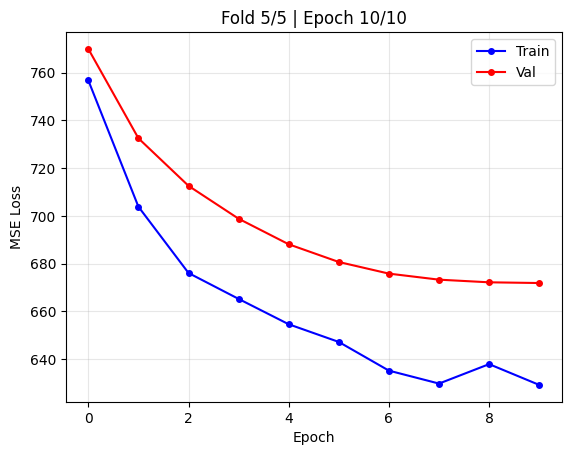

Fold 5 | Val Loss: 671.8727 | R2: -87.6305 | MAE: 25.7736

ИТОГИ КРОСС-ВАЛИДАЦИИ
R2:  -124.9467 +/- 41.9768
MAE: 24.8433 (log space)


In [ ]:
# @title Обучение с кросс-валидацией

kf = KFold(n_splits=5, shuffle=True, random_state=42)
batch_size = 2
epochs = 10
lr = 1e-5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_grouped)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/5 | Train: {len(train_idx)} обр., Val: {len(val_idx)} обр.")

    X_train = torch.tensor(X_grouped[train_idx], dtype=torch.float32)
    y_train = torch.tensor(y_grouped[train_idx], dtype=torch.float32).unsqueeze(-1)
    mask_train = torch.tensor(mask_grouped[train_idx], dtype=torch.bool)

    X_val = torch.tensor(X_grouped[val_idx], dtype=torch.float32)
    y_val = torch.tensor(y_grouped[val_idx], dtype=torch.float32).unsqueeze(-1)
    mask_val = torch.tensor(mask_grouped[val_idx], dtype=torch.bool)

    train_ds = TensorDataset(X_train, mask_train, y_train)
    val_ds = TensorDataset(X_val, mask_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = MultiPDTransformer(
    d_model=256,        # 128 → 256
    nhead=8,            # 4 → 8
    num_layers_pd=4,    # 2 → 4
    num_layers_agg=4,   # 2 → 4
    dim_feedforward=512,# 256 → 512
    dropout=0.3,        # 0.2 → 0.3 (больше регуляризации)
    max_len=2000
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}
    plt.figure(figsize=(10, 4))

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        pbar = tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for Xb, mb, yb in pbar:
            Xb, mb, yb = Xb.to(device), mb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, mb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            pbar.set_postfix(loss=loss.item())
        train_loss /= len(train_ds)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []
        pbar = tqdm(val_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for Xb, mb, yb in pbar:
                Xb, mb, yb = Xb.to(device), mb.to(device), yb.to(device)
                preds = model(Xb, mb)
                loss = criterion(preds, yb)
                val_loss += loss.item() * Xb.size(0)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(yb.cpu().numpy())
                pbar.set_postfix(loss=loss.item())
        val_loss /= len(val_ds)
        history['val_loss'].append(val_loss)
        scheduler.step()

        clear_output(wait=True)
        plt.clf()
        plt.plot(history['train_loss'], 'b-o', markersize=4, label='Train')
        plt.plot(history['val_loss'], 'r-o', markersize=4, label='Val')
        plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
        plt.title(f'Fold {fold+1}/5 | Epoch {epoch+1}/{epochs}')
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.show()

    all_preds = np.vstack(all_preds).flatten()
    all_targets = np.vstack(all_targets).flatten()
    r2 = r2_score(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)

    fold_metrics.append({'r2': r2, 'mae': mae, 'val_loss': val_loss})
    print(f"Fold {fold+1} | Val Loss: {val_loss:.4f} | R2: {r2:.4f} | MAE: {mae:.4f}")

print(f"\n{'='*50}")
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print(f"{'='*50}")
r2_mean = np.mean([m['r2'] for m in fold_metrics])
r2_std = np.std([m['r2'] for m in fold_metrics])
mae_mean = np.mean([m['mae'] for m in fold_metrics])
print(f"R2:  {r2_mean:.4f} +/- {r2_std:.4f}")
print(f"MAE: {mae_mean:.4f} (log space)")

## Эксперимент с обучением по каждой фильтрации каждого образца как отдельного сэмпла

In [45]:
# @title PDDataset и collate_fn

class PDDataset(Dataset):
    def __init__(self, X_list, y_array):
        self.X = X_list
        self.y = y_array

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        points = torch.tensor(self.X[idx], dtype=torch.float32)
        target = torch.tensor(self.y[idx], dtype=torch.float32).unsqueeze(-1)
        return points, target

def collate_fn(batch):
    max_len = max(p.shape[0] for p, _ in batch)
    B = len(batch)
    padded = torch.zeros(B, max_len, 3)
    mask = torch.ones(B, max_len, dtype=torch.bool)
    targets = torch.zeros(B, 1)

    for i, (points, t) in enumerate(batch):
        n = points.shape[0]
        padded[i, :n] = points
        mask[i, :n] = False
        targets[i] = t

    return padded, mask, targets

In [46]:
# @title Класс PersistenceTransformer

class PersistenceTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=4, num_layers=3,
                 dim_feedforward=256, dropout=0.1, max_len=2000):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.max_len = max_len

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, points, mask=None):
        B, N, _ = points.shape
        if N > self.max_len:
            points = points[:, :self.max_len, :]
            if mask is not None:
                mask = mask[:, :self.max_len]
            N = self.max_len

        x = self.input_proj(points) + self.pos_embed[:, :N, :]
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        if mask is not None:
            mask = torch.cat([torch.zeros(B, 1, dtype=torch.bool, device=mask.device), mask], dim=1)

        x = self.transformer(x, src_key_padding_mask=mask)
        return self.head(x[:, 0, :])

In [47]:
# @title Нормализация координат и диагностика данных

# 1. Проверка и очистка X_list от NaN/inf (на всякий случай)
import numpy as np

print("Проверка X_list...")
for i, pts in enumerate(X_list):
    if np.isnan(pts).any() or np.isinf(pts).any():
        print(f"  Образец {i}: есть nan/inf, заменяем")
        pts = np.nan_to_num(pts, nan=0.0, posinf=0.0, neginf=0.0)
        X_list[i] = pts

# 2. Нормализация координат birth и death (столбцы 1 и 2)
all_pts = np.vstack([p[:, 1:] for p in X_list])  # только birth и death
mean_bd = all_pts.mean(axis=0)
std_bd = all_pts.std(axis=0) + 1e-8
print(f"Нормализация: mean={mean_bd}, std={std_bd}")

for i in range(len(X_list)):
    X_list[i][:, 1:] = (X_list[i][:, 1:] - mean_bd) / std_bd

# 3. Проверка y_array
print(f"y_array min={y_array.min()}, max={y_array.max()}, any nan={np.isnan(y_array).any()}")

# Теперь данные готовы, можно создавать PDDataset и запускать обучение

Проверка X_list...
Нормализация: mean=[105.66 182.39], std=[  71.83 5561.24]
y_array min=-37.666011810302734, max=-24.90303611755371, any nan=False


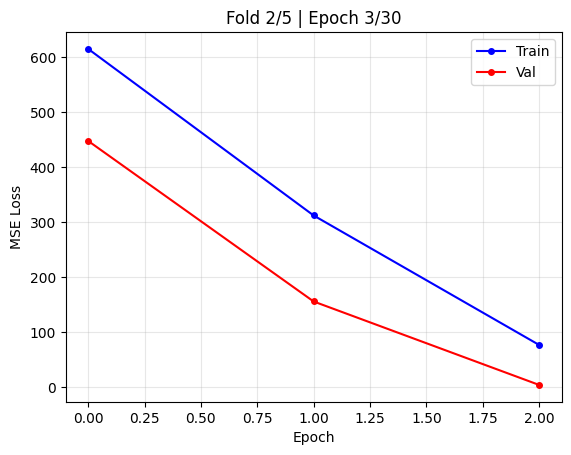

Fold 2 Epoch 4/30 [Train]:  12%|█████████▏                                                                    | 30/256 [00:06<00:48,  4.67it/s, loss=20.6]

In [ ]:
# @title Обучение PersistenceTransformer на всех ПД (GroupKFold)

# ---------- Настройки ----------
batch_size = 32
epochs = 30
lr = 1e-4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Создаём датасет
dataset_pd = PDDataset(X_list, y_array)

gkf = GroupKFold(n_splits=5)
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_list, y_array, groups)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/5 | Train: {len(train_idx)} ПД, Val: {len(val_idx)} ПД")

    # Загрузчики
    train_ds = Subset(dataset_pd, train_idx)
    val_ds = Subset(dataset_pd, val_idx)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # Модель (PersistenceTransformer)
    model = PersistenceTransformer(
        d_model=128, nhead=4, num_layers=3,
        dim_feedforward=256, dropout=0.2, max_len=2000
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}
    plt.figure(figsize=(10, 4))
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        pbar = tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for points, mask, targets in pbar:
            points, mask, targets = points.to(device), mask.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(points, mask), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * points.size(0)
            pbar.set_postfix(loss=loss.item())
        train_loss /= len(train_ds)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []
        pbar = tqdm(val_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for points, mask, targets in pbar:
                points, mask, targets = points.to(device), mask.to(device), targets.to(device)
                preds = model(points, mask)
                loss = criterion(preds, targets)
                val_loss += loss.item() * points.size(0)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(targets.cpu().numpy())
                pbar.set_postfix(loss=loss.item())
        val_loss /= len(val_ds)
        history['val_loss'].append(val_loss)
        scheduler.step()
        if epoch % 5 == 0:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_loss': val_loss,
                'r2': r2 if 'r2' in locals() else None
            }
            torch.save(checkpoint, f"checkpoint_fold{fold+1}_epoch{epoch+1}.pth")

        # отдельно сохраняем лучшую модель
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f"best_model_fold{fold+1}.pth")

        clear_output(wait=True)
        plt.clf()
        plt.plot(history['train_loss'], 'b-o', markersize=4, label='Train')
        plt.plot(history['val_loss'], 'r-o', markersize=4, label='Val')
        plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
        plt.title(f'Fold {fold+1}/5 | Epoch {epoch+1}/{epochs}')
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.show()

    all_preds = np.vstack(all_preds).flatten()
    all_targets = np.vstack(all_targets).flatten()
    r2 = r2_score(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)

    fold_metrics.append({'r2': r2, 'mae': mae, 'val_loss': val_loss})
    print(f"Fold {fold+1} | Val Loss: {val_loss:.4f} | R2: {r2:.4f} | MAE: {mae:.4f}")

print(f"\n{'='*50}")
print("ИТОГИ")
print(f"R2:  {np.mean([m['r2'] for m in fold_metrics]):.4f} ± {np.std([m['r2'] for m in fold_metrics]):.4f}")
print(f"MAE: {np.mean([m['mae'] for m in fold_metrics]):.4f}")

## Инференс

In [49]:
#@title Загрузка сохранённых моделей для тестов и предсказаний в инференсе

def load_model(path, device):
    model = PersistenceTransformer(d_model=128, nhead=4, num_layers=3,
                                   dim_feedforward=256, dropout=0.2, max_len=2000)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    return model


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
models = [load_model(f"best_model_fold{i}.pth", device) for i in range(1, 6)]


def predict_ensemble(points, mask):
    """points, mask — батч (B, N, 3) и (B, N)"""
    preds = []
    with torch.no_grad():
        for m in models:
            preds.append(m(points.to(device), mask.to(device)).cpu())
    return torch.stack(preds).mean(dim=0)  # усреднение

In [62]:
#@title Функция подготовки ПД для образца для инференса

def prepare_single_pd(cube, filt_func, norm_stats, max_points=2000):
    # 1. grayscale и вычисление ПД
    grayscale = filt_func(cube)
    points = compute_diagrams_cripser(grayscale)

    # 2. Замена inf на максимальное конечное значение (для birth и death)
    for col_idx in (1, 2):          # birth и death
        col = points[:, col_idx]
        inf_mask = np.isinf(col)
        if inf_mask.any():
            finite = col[~inf_mask]
            max_finite = finite.max() if len(finite) > 0 else 1.0
            points[inf_mask, col_idx] = max_finite * 1.1

    # 3. Обрезка до top‑max_points по персистентности
    if points.shape[0] > max_points:
        pers = points[:, 2] - points[:, 1]
        idx = np.argsort(np.abs(pers))[::-1][:max_points]
        points = points[idx]

    if len(points) == 0:
        return None, None

    # 4. Нормализация
    points[:, 1] = (points[:, 1] - norm_stats['mean_birth']) / (norm_stats['std_birth'] + 1e-8)
    points[:, 2] = (points[:, 2] - norm_stats['mean_death']) / (norm_stats['std_death'] + 1e-8)

    if np.isnan(points).any() or np.isinf(points).any():
        return None, None

    # 5. В тензоры
    points_t = torch.tensor(points, dtype=torch.float32).unsqueeze(0).to(device)
    mask_t = torch.zeros(1, points_t.shape[1], dtype=torch.bool, device=device)
    return points_t, mask_t

In [ ]:
#@title Словарь со значениями LBM для синтетики для удобства

true_lbm_dict = {}
for i in range(len(dataset)):
    if dataset.samples[i]['type'] == 'synth':
        _, target, name = dataset[i]
        true_lbm_dict[name] = target[5].item()

In [105]:
pd_dir = "persistent_diagrams_synthetic"          # ваша папка с результатами
max_points = 2000                                  # как при обучении

all_birth = []
all_death = []

pkl_files = [f for f in os.listdir(pd_dir) if f.endswith("_pd.pkl")]

for fname in tqdm(pkl_files, desc="Сбор статистик"):
    with open(os.path.join(pd_dir, fname), "rb") as f:
        points = pickle.load(f)["diagrams"]
    points = points[:, [2, 0, 1]]       # (N, 3): dim, birth, death
    # --- Очистка от inf и обрезка (точно как при инференсе) ---
    for col_idx in (1, 2):                        # birth и death
        col = points[:, col_idx]
        inf_mask = np.isinf(col)
        if inf_mask.any():
            finite = col[~inf_mask]
            max_finite = finite.max() if len(finite) > 0 else 1.0
            points[inf_mask, col_idx] = max_finite * 1.1

    if points.shape[0] > max_points:
        pers = points[:, 2] - points[:, 1]
        idx = np.argsort(np.abs(pers))[::-1][:max_points]
        points = points[idx]

    if len(points) == 0:
        continue

    all_birth.append(points[:, 1])
    all_death.append(points[:, 2])

# Объединяем и убираем возможные inf (хотя после очистки их быть не должно)
all_birth = np.concatenate(all_birth)
all_death = np.concatenate(all_death)
all_birth = all_birth[np.isfinite(all_birth)]
all_death = all_death[np.isfinite(all_death)]

norm_stats_synthetic = {
    "mean_birth": float(all_birth.mean()),
    "std_birth":  float(all_birth.std()),
    "mean_death": float(all_death.mean()),
    "std_death":  float(all_death.std()),
}

Сбор статистик: 100%|████████████████████████████████████████████████████████████████| 2201/2201 [00:05<00:00, 374.87it/s]


In [111]:
#@title Инференс

data_dir = "synthetic_data_extracted/npy_256"
sample_files = ["structure_11.npy"]  # или список нужных файлов

results = []
for fname in tqdm(sample_files, desc="Образцы"):
    cube = np.load(os.path.join(data_dir, fname)).astype(np.uint8)

    all_log_preds = []
    for filt_name in tqdm(ALL_FILTRATIONS, desc="Фильтрации", leave=False):
        points_t, mask_t = prepare_single_pd(cube, ALL_FILTRATIONS[filt_name], norm_stats_synthetic)
        if points_t is None:
            print(f"  {filt_name}: пропущена")
            continue
        avg_pred = predict_ensemble(points_t, mask_t).item()
        if np.isnan(avg_pred):
            print(f"  {filt_name}: nan")
            continue
        else:
            print(print(f"  {filt_name}: {avg_pred}"))
        all_log_preds.append(avg_pred)

    if not all_log_preds:
        log_lbm, abs_lbm = float('nan'), float('nan')
    else:
        log_lbm = np.mean(all_log_preds)
        abs_lbm = np.exp(log_lbm)

    sample_name = fname.replace('.npy', '')
    true_abs = true_lbm_dict.get(sample_name, None)
    results.append((sample_name, log_lbm, abs_lbm, true_abs))

# Вывод результатов
print(f"{'Образец':<20} {'log(LBM)':>10} {'Предск. LBM':>12} {'Истинный LBM':>14}")
for name, logv, absv, truev in results:
    true_str = f"{truev:.4e}" if truev is not None else "N/A"
    print(f"{name:<20} {logv:10.4f} {absv:12.4e} {true_str:>14}")

Фильтрации:   1%|▉                                                                         | 1/81 [00:35<47:00, 35.25s/it]

  radial_0_0_0: -21.0966854095459
None



Фильтрации:   2%|█▊                                                                        | 2/81 [01:04<42:02, 31.93s/it]

  radial_0_0_1: -21.1458683013916
None



Фильтрации:   4%|██▋                                                                       | 3/81 [01:34<40:24, 31.08s/it]

...

  radial_1_2_1: -21.105253219604492
None



Фильтрации:  22%|████████████████▏                                                        | 18/81 [08:59<31:16, 29.79s/it]

  radial_1_2_2: -21.17099380493164
None



Образцы:   0%|                                                                                      | 0/1 [09:27<?, ?it/s]


KeyboardInterrupt: 

In [107]:
print("Реальные:", norm_stats)
print("Синтетические:", norm_stats_synthetic)

Реальные: {'mean_birth': 105.65832279905014, 'std_birth': 71.82864306269713, 'mean_death': 182.39315340882985, 'std_death': 5561.2366693900785}
Синтетические: {'mean_birth': 105.25917776343834, 'std_birth': 64.71468071839826, 'mean_death': 173.9171117042842, 'std_death': 93.51994542248886}


In [104]:
for fname in sorted(os.listdir("persistent_diagrams_synthetic"))[:3]:
    with open(os.path.join("persistent_diagrams_synthetic", fname), 'rb') as f:
        data = pickle.load(f)
    pts = data['diagrams']
    print(f"{fname}: dim={pts[:,0].min()}-{pts[:,0].max()}, birth min/max={pts[:,1].min():.2f}/{pts[:,1].max():.2f}, death min/max={pts[:,2].min():.2f}/{pts[:,2].max():.2f}, any inf={np.isinf(pts).any()}")

structure_10_density_pd.pkl: dim=4.0-122.0, birth min/max=18.00/inf, death min/max=0.00/2.00, any inf=True
structure_10_dilation_pd.pkl: dim=0.0-0.0, birth min/max=23.00/inf, death min/max=0.00/2.00, any inf=True
structure_10_erosion_pd.pkl: dim=1.0-34.0, birth min/max=2.00/inf, death min/max=0.00/2.00, any inf=True


In [112]:
def show_first_3_points(pkl_path):
    with open(pkl_path, 'rb') as f:
        points = pickle.load(f)['diagrams']

    # Если первый столбец не содержит только 0,1,2 – значит порядок (birth, death, dim)
    if not np.all(np.isin(points[:, 0], [0, 1, 2])):
        print("Порядок столбцов: (birth, death, dim)")
        print("Первые 3 точки (birth, death, dim):")
        print(points[:3])
        # для удобства покажем и правильный порядок
        corrected = points[:, [2, 0, 1]]
        print("\nПосле исправления (dim, birth, death):")
        print(corrected[:3])
    else:
        print("Порядок столбцов уже (dim, birth, death)")
        print("Первые 3 точки (dim, birth, death):")
        print(points[:3])

In [114]:
show_first_3_points("persistent_diagrams_height/10_01_256_height_diag_---_pd.pkl")

Порядок столбцов: (birth, death, dim)
Первые 3 точки (birth, death, dim):
[[0.09 0.49 0.  ]
 [0.09 0.49 0.  ]
 [0.09 0.49 0.  ]]

После исправления (dim, birth, death):
[[0.   0.09 0.49]
 [0.   0.09 0.49]
 [0.   0.09 0.49]]
